In [600]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.utils import resample
from scipy.stats import norm
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

A:OLS for the Runge function
-

Write your own code (using for example the pseudoinverse function pinv from numpy, or
the SVD directly) and perform a standard ordinary least squares regression analysis using
polynomials in x up to order 15 or higher.

In [601]:
def runge(x):
    return (1.0/(1.0+25*x**2)) #The runge function

def design_matrix(x, degree):
    X = np.vander(np.asarray(x).ravel(), degree +1 , increasing=True) #creating the design matrix. [1, x, x^2.. X^n]
    return X
#parameters for the runge function
rng = np.random.default_rng(2026)
n = 100
sigma = 0.1
x = np.sort(rng.uniform(-1,1,n))
y = runge(x) + rng.normal(0, sigma,n)


def exercisedata(x, y, d):
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=2026) #Splitting the data
    scaler = StandardScaler() #Int the scaling for polynomial feauters
    Xtr = design_matrix(x_train, d) #Create train X matrix
    Xtr_sc = np.copy(Xtr)
    Xtr_sc[:,1:] = scaler.fit_transform(Xtr[:,1:])  #Fit the training on training feauteres and standarize. 
    
    Xte = design_matrix(x_test, d) #Create test X matrix
    Xte_sc = np.copy(Xte) 
    Xte_sc[:,1:] = scaler.transform(Xte[:,1:]) #Standarize the testdata using the training means and scales.
    theta = np.linalg.lstsq(Xtr_sc, y_train, rcond=None)[0] #Computeing the OLS coeff using training data

    return theta, Xtr_sc, Xte_sc, y_train, y_test 


degrees = np.arange(1,16)
mse_train, mse_test = [], [] #Initialize empty list for test and train MSE, R" scores and theta values
R2_train, R2_test = [], []
theta_values = []

for d in degrees:
    theta, Xtr_sc, Xte_sc, y_train, y_test = exercisedata(x, y, d)  #Fit the OLS model for degree d and retrive scaled data
    theta_values.append(theta) #Store coeff for current data
    y_train_pred = Xtr_sc @ theta #Commpute training and test predictions.
    y_test_pred = Xte_sc @ theta 
    mse_train.append(mean_squared_error(y_train, y_train_pred)) #Storing/Compute curent test, train MSE and R2 scores
    mse_test.append(mean_squared_error(y_test, y_test_pred)) 
    R2_train.append(r2_score(y_train, y_train_pred)) 
    R2_test.append(r2_score(y_test, y_test_pred)) 

Lowest Test MSE: 0.018711534420669352 Measured at degree: 8


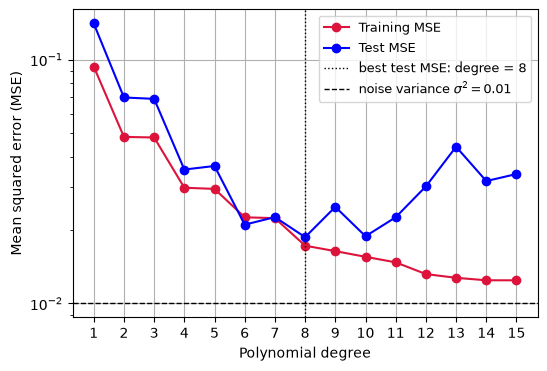

In [602]:
best_idx = int(np.argmin(mse_test)) #OLS Plot for MSE as a function of the polynomial degrees. 
best_degree = degrees[best_idx]
print("Lowest Test MSE:", mse_test[best_idx],"Measured at degree:", best_degree)
plt.figure(figsize=(6,4))
plt.plot(degrees, mse_train, "o-", color = "crimson", label = "Training MSE")
plt.plot(degrees, mse_test, "o-", color = "blue", label = "Test MSE")
plt.axvline(best_degree, color = "k", ls = ":", lw=1, label=f"best test MSE: degree = {best_degree}")
plt.axhline(0.1**2, color = "k", ls = "--", lw=1, label=f"noise variance $\sigma ^2 = 0.01$")
plt.xlabel("Polynomial degree"); plt.ylabel("Mean squared error (MSE)"); plt.xticks(degrees); plt.legend(fontsize=9), plt.grid(True)
plt.yscale("log"); plt.savefig("figures/ols_mse.png", dpi=300, bbox_inches="tight");plt.show()

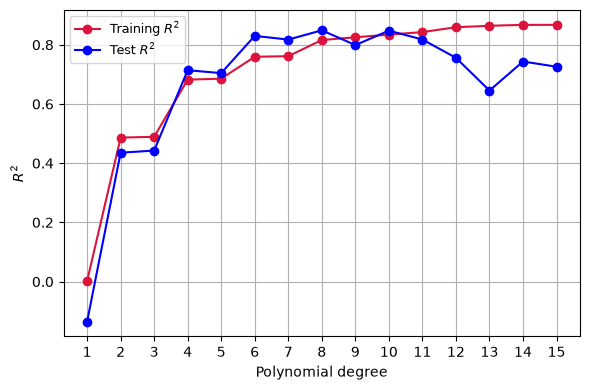

In [603]:
plt.figure(figsize=(6,4)); plt.plot(degrees, R2_train, "o-", color = "crimson", label = "Training $R^2$")  #OLS Plot for R2 score as a function of the polynomial degrees. 
plt.plot(degrees, R2_test, "o-", color = "blue", label = "Test $R^2$")
plt.xlabel("Polynomial degree"); plt.ylabel("$R^2$"); plt.xticks(degrees); plt.legend(fontsize=9),
plt.grid(True); plt.tight_layout();plt.savefig("figures/ols_R2.png", dpi=300, bbox_inches="tight");plt.show()

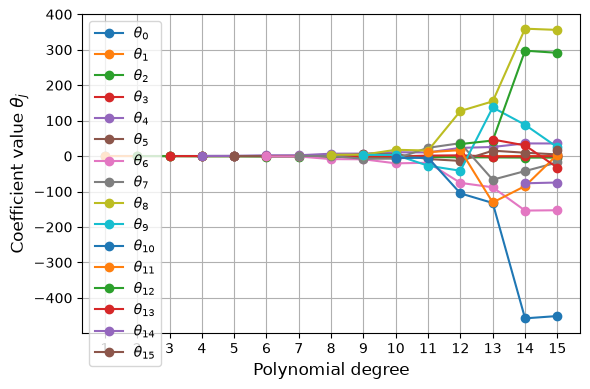

In [604]:
max_degree = max(degrees) # #OLS coeffecients as a function of the polynomial degrees. 

plt.figure(figsize=(6, 4))

for j in range(max_degree + 1):
    theta_j = [theta[j] if j < len(theta) else np.nan for theta in theta_values]
    plt.plot(degrees, theta_j, "o-", label=rf"$\theta_{{{j}}}$")

plt.xlabel("Polynomial degree", fontsize = 12)
plt.ylabel(r"Coefficient value $\theta_j$", fontsize = 12)
plt.xticks(degrees)
plt.grid(True)
plt.legend()
plt.legend(fontsize=10)
plt.savefig("figures/ols_coeff_mse.png", dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()

n = 40: Laveste test-MSE = 0.021463, optimal grad = 6
n = 100: Laveste test-MSE = 0.018712, optimal grad = 8
n = 400: Laveste test-MSE = 0.010047, optimal grad = 15


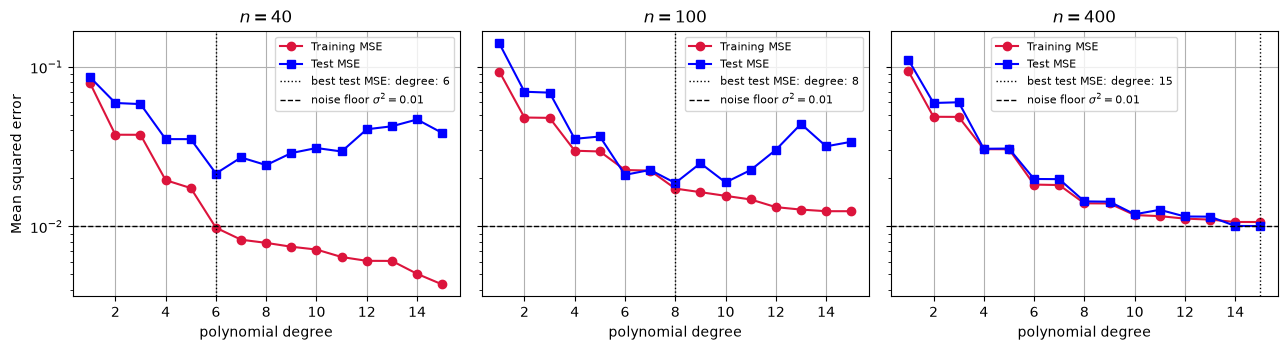

s = 0.01: Laveste test-MSE = 0.001343, optimal grad = 15
s = 0.1: Laveste test-MSE = 0.018712, optimal grad = 8
s = 1.0: Laveste test-MSE = 1.251303, optimal grad = 2


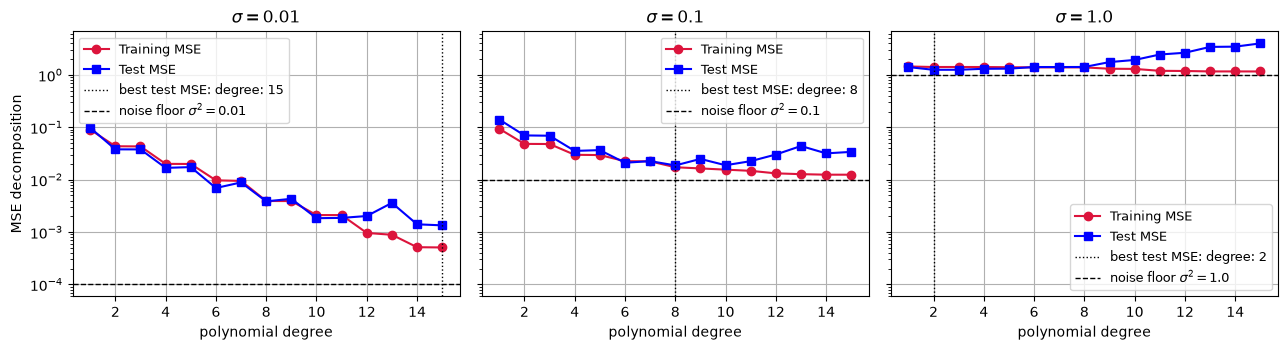

In [605]:
def runge_data(degree, n=100, sigma = 0.1, seed = 2026): #
    rng = np.random.default_rng(seed) #Initialize random number generator
    x = np.sort(rng.uniform(-1, 1, n))
    y = runge(x) + rng.normal(0, sigma, n)
    
    mse_tr_c, mse_te_c, theta_values = [], [], [] #Creating empty list to store values

    for d in degree: #For every degree
        theta, Xtr_sc, Xte_sc, y_train, y_test =  exercisedata(x, y, d) #Fit the model for degree d and scale the data
    
        theta_values.append(theta) #Storing the current coeffecient
        y_train_pred = Xtr_sc @ theta #Compute train and test predictions
        y_test_pred = Xte_sc @ theta

        mse_tr_c.append(mean_squared_error(y_train, y_train_pred)) #Compute train and test MSE
        mse_te_c.append(mean_squared_error(y_test, y_test_pred))

    return np.array(mse_tr_c), np.array(mse_te_c), theta_values

results = [] #Creating an empty list
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), sharey=True) #Plot train and test MSE for different number of data points
for ax, n_ in zip(axes, (40, 100, 400)):
    mse_tr, mse_te, _ = runge_data(degree=degrees, n=n_, sigma=0.1, seed=2026)
    best_idx = int(np.argmin(mse_te))
    best_degree = degrees[best_idx]
    best_mse = mse_te[best_idx]

    print(f"n = {n_}: Laveste test-MSE = {best_mse:.6f}, "f"optimal grad = {best_degree}")
    results.append({
    "Antall datapunkter": n_,
    "Optimal grad": best_degree,
    "Laveste test-MSE": best_mse})

    ax.plot(degrees, mse_tr,"o-", color = "crimson", label = "Training MSE")
    ax.plot(degrees, mse_te,"s-", color = "b", label = f"Test MSE")
    ax.axvline(best_degree, color = "k", ls = ":", lw=1, label=f"best test MSE: degree: {best_degree}")
    ax.axhline(0.1**2, color = "k", ls = "--", lw=1, label=f"noise floor $\sigma ^2 = 0.01$")
    ax.set_yscale("log")
    ax.set_title(f"$n = {n_}$")
    ax.set_xlabel("polynomial degree")
    ax.grid(True)
    ax.legend(fontsize= 8)

axes[0].set_ylabel("Mean squared error")
plt.savefig("figures/OLS_mse_s.png", dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()

results = []
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), sharey=True) #Plot train and test MSE for noise values
for ax, s_ in zip(axes, (0.01, 0.1, 1.0)):
    mse_tr, mse_te, _ = runge_data(degree=degrees, n=100, sigma = s_, seed = 2026)
    best_idx = int(np.argmin(mse_te))
    best_degree = degrees[best_idx]
    best_mse = mse_te[best_idx]
    print(f"s = {s_}: Laveste test-MSE = {best_mse:.6f}, "f"optimal grad = {best_degree}")
    results.append({"noise": s_,
        "Optimal grad": best_degree,
        "Laveste test-MSE": best_mse})
    ax.plot(degrees, mse_tr,"o-", color = "crimson", label = "Training MSE")
    ax.plot(degrees, mse_te,"s-", color = "b", label = f"Test MSE")
    ax.axvline(best_degree, color = "k", ls = ":", lw=1, label=f"best test MSE: degree: {best_degree}")
    ax.axhline(s_**2, color = "k", ls = "--", lw=1, label=f"noise floor $\sigma ^2 = {s_}$")
    ax.set_yscale("log")
    ax.set_title(f"$\sigma = {s_}$")
    ax.set_xlabel("polynomial degree")
    ax.legend(fontsize= 9)
    ax.grid(True)

axes[0].set_ylabel("MSE decomposition")
plt.legend(fontsize= 9); plt.grid(True)
plt.savefig("figures/OLS_mse_n.png", dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()



B: Adding Ridge regression for the Runge function
-

In [606]:
best_results = [] #Creating empty 
lambdas = np.logspace(-6,0,100) #Creating a grid for the regularization parameter
degree = np.arange(1,16)
for d in degree:

    theta, Xtr_sc, Xte_sc, yr_train, yr_test = exercisedata(x, y, d) #Fit the Ridge model for degree d and retrive scaled data
    I = np.eye(Xtr_sc.shape[1])  #Creating a penalty matrix to avoid intercept for regularization. 
    I[0,0] = 0  
    mse_r_train, mse_r_test = [], [] #Initalizing list for data
    R2_r_train, R2_r_test = [], []
    theta_r_values = []
    for l in lambdas:

        theta_r = np.linalg.solve(Xtr_sc.T @ Xtr_sc + len(yr_train)*l*I, Xtr_sc.T@yr_train) #Computing the Ridge coeffecients
        theta_r_values.append(theta_r)

        yr_train_pred = Xtr_sc@ theta_r #Computing test and train predictions
        yr_test_pred = Xte_sc @ theta_r

        mse_r_train.append(mean_squared_error(yr_train, yr_train_pred)) #Computing test and train MSE
        mse_r_test.append(mean_squared_error(yr_test, yr_test_pred))

        R2_r_train.append(r2_score(yr_train, yr_train_pred))#Computing test and train R2 scores
        R2_r_test.append(r2_score(yr_test, yr_test_pred))
    best_idx = int(np.argmin(mse_r_test)) #Collecting the lambda value with the min MSE for the current degree
    best_results.append((d, lambdas[best_idx], mse_r_test[best_idx])) 

    theta_r_values = np.array(theta_r_values)

best_degree, best_lambda, best_mse = min(best_results, key=lambda result: result[2]) #Find the degre-lambda combo with the min test MSE

print("Beste grad:", best_degree)
print("Beste lambda:", best_lambda)
print("Laveste test-MSE:", best_mse)

Beste grad: 8
Beste lambda: 1.873817422860383e-05
Laveste test-MSE: 0.01765544134057781


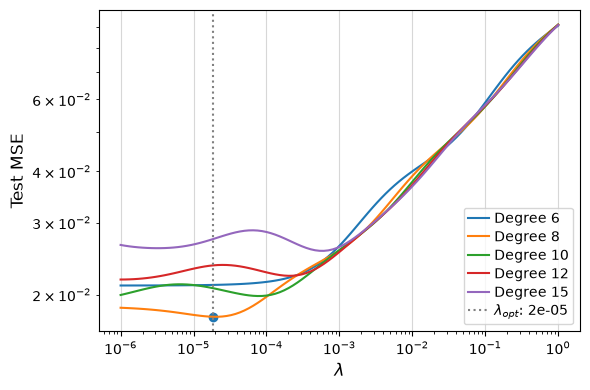

Lowest test MSE: 0.01766
Degree: 8
Lambda: 1.87e-05


In [607]:
#Plotting test MSE for Ridge for certain degrees as a function of lambda
plt.figure(figsize=(6,4))
best = (np.inf, None, None)  
degrees = [6, 8, 10, 12, 15]
for d in degrees:
    _, Xtr_sc, Xte_sc, yr_train, yr_test = exercisedata(x, y, d)

    I = np.eye(Xtr_sc.shape[1])
    I[0, 0] = 0  
    mse_test = []

    for lam in lambdas:
        theta = np.linalg.solve(Xtr_sc.T @ Xtr_sc + len(yr_train) * lam * I,Xtr_sc.T @ yr_train)
        mse = mean_squared_error(yr_test, Xte_sc @ theta)
        mse_test.append(mse)

        if mse < best[0]:
            best = (mse, d, lam)

    plt.loglog(lambdas, mse_test, label=f"Degree {d}")

plt.axvline(best[2], color="gray", ls=":", label=r"$\lambda_{opt}$:" rf" {best[2]:.1g}")
plt.scatter(best[2], best[0]);plt.xlabel(r"$\lambda$", fontsize=12);plt.ylabel("Test MSE", fontsize=12)
plt.legend(loc="lower right",fontsize=10,borderpad=0.3,labelspacing=0.3,handlelength=1.5,handletextpad=0.4)
plt.grid(True, which="major", alpha=0.5); plt.savefig("figures/Ridge_mse.png", dpi=300, bbox_inches="tight")
plt.tight_layout()

plt.show()
print(f"Lowest test MSE: {best[0]:.5f}")
print(f"Degree: {best[1]}")
print(f"Lambda: {best[2]:.3g}")

In [608]:
theta, Xtr_sc, Xte_sc, yr_train, yr_test = exercisedata(x, y, d=8) #Plotting the R2 score for test and train MSE as a function of lambda
I = np.eye(Xtr_sc.shape[1])
I[0,0] = 0
mse_r_train, mse_r_test = [], []
R2_r_train, R2_r_test = [], []
theta_r_values = []
lambdas = np.logspace(-6,0,100)
degree = np.arange(1,16)
for l in lambdas:

    theta_r = np.linalg.solve(Xtr_sc.T @ Xtr_sc + len(y_train)*l*I, Xtr_sc.T@yr_train)
    theta_r_values.append(theta_r)

    yr_train_pred = Xtr_sc@ theta_r
    yr_test_pred = Xte_sc @ theta_r

    mse_r_train.append(mean_squared_error(yr_train, yr_train_pred))
    mse_r_test.append(mean_squared_error(yr_test, yr_test_pred))

    R2_r_train.append(r2_score(yr_train, yr_train_pred))
    R2_r_test.append(r2_score(yr_test, yr_test_pred))

theta_r_values = np.array(theta_r_values)

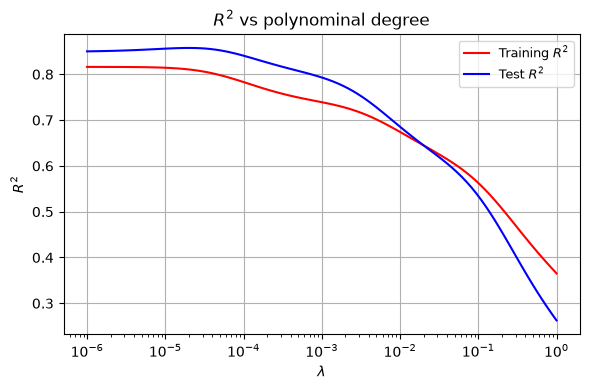

In [609]:
plt.figure(figsize=(6,4))
plt.semilogx(lambdas, R2_r_train, color = "r", label = "Training $R^2$")
plt.semilogx(lambdas, R2_r_test, color = "blue", label = "Test $R^2$")
plt.xlabel(fr"$\lambda$"); plt.ylabel("$R^2$"); plt.legend(fontsize=9),
plt.grid(True); plt.title("$R^2$ vs polynominal degree"); plt.savefig("figures/Ridge_R2.png", dpi=300, bbox_inches="tight");plt.tight_layout();plt.show()

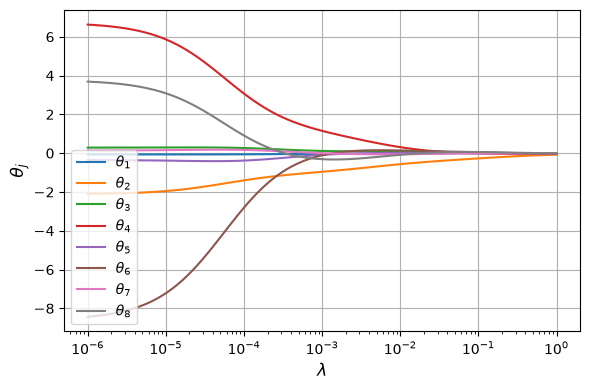

In [610]:
plt.figure(figsize=(6,4)) #Plotting the Ridge coeffecients as a function of lambda
for j in range(1, theta_r_values.shape[1]):
    plt.semilogx(lambdas, theta_r_values[:, j], label = rf"$\theta_{j}$")

plt.xlabel(r"$\lambda$", fontsize = 12); plt.ylabel(r"$\theta_j$", fontsize = 12)
plt.legend(fontsize=10); plt.savefig("figures/Ridge_coeff.png", dpi=300, bbox_inches="tight"); plt.tight_layout();plt.grid(True); plt.show()

C: The bias-variance tradeoff and the bootstrap method
-

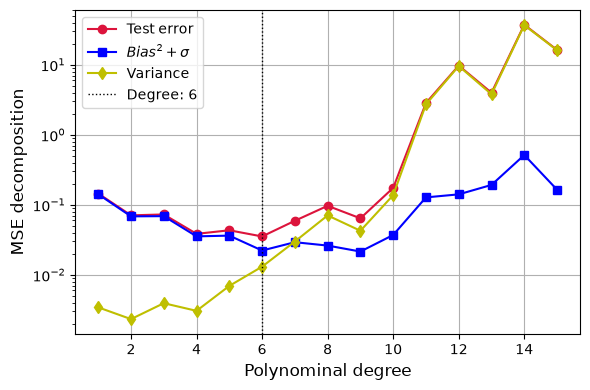

In [611]:
np.random.seed(2026) #Setting the seed
n, n_bootstrap, maxdegree = 100, 100, 15 #Define nr of datapoints, bootstrap samples and the maximum degree
degrees = np.arange(1, maxdegree +1)
rng = np.random.default_rng(2026) #Generating inputvalues
sigma = 0.1
x = np.sort(rng.uniform(-1,1,n))
x = np.asarray(x).reshape(-1, 1)
y = runge(x) + rng.normal(0, sigma, size = (n, 1))
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=2026) #create a fixed train test split dataset


error = np.zeros(maxdegree) #Initialize arrays for test error, squared bias and variance
bias = np.zeros(maxdegree)
variance = np.zeros(maxdegree)
for j, degree in enumerate(degrees): 
    model = make_pipeline(PolynomialFeatures(degree=degree), LinearRegression(fit_intercept=False)) #Create polynomial feauturs and fit OLS
    y_pred = np.empty((y_test.shape[0], n_bootstrap)) #Store one column of test predictions for each bootstrap sample
    for i in range(n_bootstrap): #Sample pair train observation with replacement
        x_, y_ = resample(x_train, y_train) #Fit on the bootstrap sample and predict on the fixed test set. 
        y_pred[:,i] = model.fit(x_, y_).predict(x_test).ravel() #

    error[j] = np.mean(np.mean((y_test - y_pred)**2, axis=1, keepdims=True)) #Average squared predictions over bootstrap samples and and test points. 
    bias[j] = np.mean((y_test - np.mean(y_pred, axis=1, keepdims=True))**2) #Compute sq. bias over noisy test targets
    variance[j] = np.mean(np.var(y_pred, axis=1, keepdims=True)) #Compute prediction variance accross bootsamples and average test points

idx = int(np.argmin(error)) #Find the polynomial degree with the lowest estimated bootstrap MSE. 
best_degree = degrees[idx]

plt.subplots(figsize=(6,4)) #Plot the squared bias, variance and estimated MSE as a function of the polynomial degree. 
plt.plot(degrees, error, "o-", color = "crimson", label = "Test error")
plt.plot(degrees, bias, "s-", color = "b", label = r"$Bias^2 + \sigma$")
plt.plot(degrees, variance, "d-", color = "y", label = "Variance")
plt.axvline(best_degree, color = "k", ls = ":", lw=1, label=f"Degree: {best_degree}")
#plt.axhline(error[idx], color = "k", ls = ":", lw=1, label=f" MSE:{error[idx]:.3f}")
plt.xlabel("Polynominal degree", fontsize=12); plt.ylabel("MSE decomposition", fontsize=12)
plt.yscale("log"); plt.legend(fontsize=10); plt.grid(True); plt.savefig("figures/OLS_Boot.png", dpi=300, bbox_inches="tight");plt.tight_layout()
plt.show()

In [612]:
print("OLS", 0.1, "Bootstrap",degrees[idx], error[idx])

OLS 0.1 Bootstrap 6 0.035344523036631235


In [613]:
def bias_variance_sweep(n=40, noise=0.1, maxdegree=14,n_bootstraps=100, make_model=None, seed=2026):
    if make_model is None:  #Use OLS as a defult unless other model is initialized
        make_model = lambda deg: make_pipeline(PolynomialFeatures(degree=deg),LinearRegression(fit_intercept=False))

    np.random.seed(seed) #Set seed and data 
    rng = np.random.default_rng(seed)

    x = np.sort(rng.uniform(-1, 1, n)).reshape(-1, 1)
    y = runge(x) + rng.normal(0, noise, size=(n, 1))

    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=seed) #Create fixed train test split
    #Empty arrays for the estimated error, bias and variance
    error, bias, variance = (np.zeros(maxdegree) for _ in range(3))
    #Create model for current polynomial degree
    for j, degree in enumerate(range(1, maxdegree + 1)):
        model = make_model(degree) #Store test predictions from each bootrap sample in seperate column
        y_pred = np.empty((y_test.shape[0], n_bootstraps))

        for i in range(n_bootstraps):#Resample paired training observation with replacement
            x_, y_ = resample(x_train, y_train)
            y_pred[:, i] = model.fit(x_, y_).predict(x_test).ravel() #Fit on sample and predict on the training set

        error[j] = np.mean((y_test - y_pred)**2) #Average squared error on the test point and boot sample
        bias[j] = np.mean((y_test - np.mean(y_pred, axis=1, keepdims=True))**2) #Average squared bias relative to the test targets
        variance[j] = np.mean(np.var(y_pred, axis=1)) #Average variance over boot prediction over test data

    return error, bias, variance

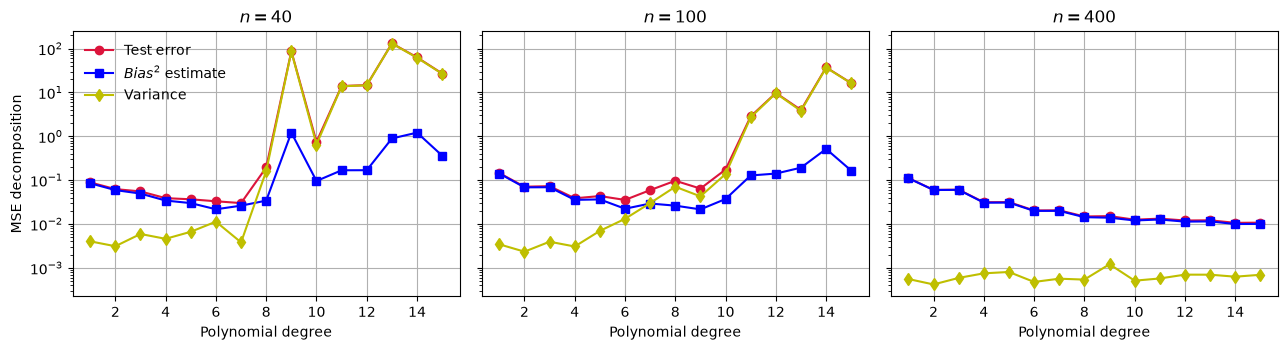

In [614]:
maxdegree = 15
degrees = np.arange(1, maxdegree + 1)
#Plot the squared bias, variance and estimated MSE as a function of the polynomial degree for three diffrent number of datapoints,
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), sharey=True)
for ax, n_ in zip(axes, (40, 100, 400)):
    err, b2, var = bias_variance_sweep(n=n_, maxdegree=maxdegree)

    ax.plot(degrees, err, "o-", color="crimson", label="Test error")
    ax.plot(degrees, b2, "s-", color="b", label=r"$Bias^2$ estimate")
    ax.plot(degrees, var, "d-", color="y", label="Variance")

    ax.set_yscale("log")
    
    ax.grid(True)
    ax.set_title(f"$n = {n_}$")
    ax.set_xlabel("Polynomial degree")

axes[0].set_ylabel("MSE decomposition")
axes[0].legend(frameon=False)
plt.savefig("figures/OLS_boot_n.png", dpi=300, bbox_inches="tight");
plt.tight_layout()
plt.show()

In [615]:
maxdegree = 15
degrees = np.arange(1, maxdegree + 1)
#Estemate OLS error, sq.bias and variance for noise = 0.05
err2, b2, var2 = bias_variance_sweep(n=100, noise=0.05, maxdegree=maxdegree)
idx2 = int(np.argmin(err2))
best_degree2 = degrees[idx2]
print(f"sigma=0.05: MSE={err2[idx2]:.4f}, degree={best_degree2}")


sigma=0.05: MSE=0.0191, degree=6


Bootstrap med Ridge

In [616]:
lambdas = np.logspace(-6, 0, 100) #Creating a logaritmic grid for the regularization parameter
rows = []
for lam in lambdas: #For every lambda create a Ridge pipeline
    def make_model(deg, lam=lam):
        return make_pipeline(PolynomialFeatures(degree=deg, #Avoid constant column 
                                                 include_bias=False), StandardScaler(),Ridge(alpha=lam)) #Standarize in each bootstrap coulmn
    err, b2, var = bias_variance_sweep(n=100,maxdegree=15,make_model=make_model) #Estimate error, sq bias and variance
    for j, d in enumerate(range(1, maxdegree + 1)): #Store eresult for each p.degree at current lambda
        rows.append({"Degree": d,"Lambda": lam,"Error": err[j],"Bias": b2[j],"Variance": var[j] })

In [617]:
table_lambda = pd.DataFrame(rows) 
best_bootstrap = table_lambda.loc[table_lambda["Error"].idxmin()]
print(f"Beste grad: {int(best_bootstrap['Degree'])}")
print(f"Beste lambda: {best_bootstrap['Lambda']:.3e}")
print(f"Bootstrap-MSE: {best_bootstrap['Error']:.5f}")

Beste grad: 6
Beste lambda: 4.037e-02
Bootstrap-MSE: 0.02987


In [618]:
best_lambda = best_bootstrap["Lambda"]
table_ridge = (table_lambda.loc[table_lambda["Lambda"] == best_lambda,["Degree", "Error", "Bias", "Variance"]].sort_values("Degree").copy())
table_ridge["Sum"] = table_ridge["Bias"] + table_ridge["Variance"]
print(f"Lambda brukt i tabellen: {best_lambda:.3e}")
print(table_ridge.to_latex(index=False, float_format="%.4f"))

Lambda brukt i tabellen: 4.037e-02
\begin{tabular}{rrrrr}
\toprule
Degree & Error & Bias & Variance & Sum \\
\midrule
1 & 0.1450 & 0.1415 & 0.0034 & 0.1450 \\
2 & 0.0708 & 0.0684 & 0.0023 & 0.0708 \\
3 & 0.0728 & 0.0689 & 0.0039 & 0.0728 \\
4 & 0.0385 & 0.0355 & 0.0030 & 0.0385 \\
5 & 0.0424 & 0.0363 & 0.0061 & 0.0424 \\
6 & 0.0299 & 0.0233 & 0.0066 & 0.0299 \\
7 & 0.0310 & 0.0232 & 0.0079 & 0.0310 \\
8 & 0.0365 & 0.0243 & 0.0122 & 0.0365 \\
9 & 0.0441 & 0.0273 & 0.0168 & 0.0441 \\
10 & 0.0429 & 0.0275 & 0.0154 & 0.0429 \\
11 & 0.0533 & 0.0305 & 0.0229 & 0.0533 \\
12 & 0.0830 & 0.0265 & 0.0565 & 0.0830 \\
13 & 0.0437 & 0.0285 & 0.0152 & 0.0437 \\
14 & 0.0521 & 0.0318 & 0.0202 & 0.0521 \\
15 & 0.0458 & 0.0309 & 0.0149 & 0.0458 \\
\bottomrule
\end{tabular}



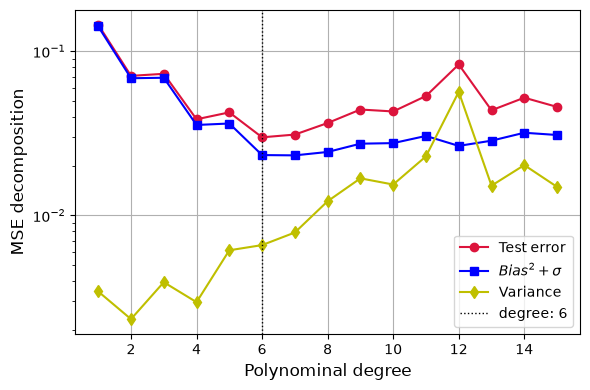

In [619]:
plt.subplots(figsize=(6,4)) #Plot for bootstrap error decomposition for Ridge
plt.plot(table_ridge["Degree"], table_ridge["Error"], "o-", color = "crimson", label = "Test error")
plt.plot(table_ridge["Degree"], table_ridge["Bias"], "s-", color = "b", label = r"$Bias^2 + \sigma$")
plt.plot(table_ridge["Degree"], table_ridge["Variance"], "d-", color = "y", label = "Variance")
plt.axvline(int(best_bootstrap['Degree']), color = "k", ls = ":", lw=1, label=f"degree: {int(best_bootstrap['Degree'])}")
#plt.axhline(best_bootstrap['Error'], color = "k", ls = ":", lw=1, label=f" MSE:{best_bootstrap['Error']:.3f}")
plt.xlabel("Polynominal degree", fontsize=12); plt.ylabel("MSE decomposition", fontsize=12)
plt.yscale("log"); plt.legend(fontsize=10); plt.grid(True); plt.savefig("figures/Ridge_Boot.png", dpi=300, bbox_inches="tight");plt.tight_layout()
plt.show()

In [620]:
lambdas = np.logspace(-6, 0, 100) 
#Esimating error, squared bias and variance for Ridge with noise at 0.05. 
rows2 = []
for lam in lambdas:
    def make_model(deg, lam=lam):
        return make_pipeline(PolynomialFeatures(degree=deg, include_bias=False), StandardScaler(),Ridge(alpha=lam))
    err, b2, var = bias_variance_sweep(n=100,noise=0.05, maxdegree=15,make_model=make_model)
    for j, d in enumerate(range(1, maxdegree + 1)): 
        rows2.append({"Degree": d,"Lambda": lam,"Error": err[j],"Bias": b2[j],"Variance": var[j] })

In [621]:
table_lambda2 = pd.DataFrame(rows2)
best_bootstrap2 = table_lambda2.loc[table_lambda2["Error"].idxmin()]
print(f"Beste grad: {int(best_bootstrap2['Degree'])}")
print(f"Beste lambda: {best_bootstrap2['Lambda']:.3e}")
print(f"Bootstrap-MSE: {best_bootstrap2['Error']:.5f}")

Beste grad: 7
Beste lambda: 4.642e-02
Bootstrap-MSE: 0.01363


D: Cross-validation as a resampling technique
-

In [622]:
mx_degree = 15 #The polynomial degrees to evaluate
degrees = np.arange(1, mx_degree +1)
rng = np.random.default_rng(2026)#Generating the runge data with Gaussian noise
n = 100
sigma = 0.1
x = np.sort(rng.uniform(-1,1,n))
y = runge(x) + rng.normal(0, sigma,n)

def ols_k_fold(x,y, mx_degree, n_splits=5):
    
    x = np.asarray(x).reshape(-1, 1) #Reshape data to compare with sklearn
    y = np.asarray(y).ravel()
    kf = KFold(n_splits, shuffle = True, random_state=2026) #Define shuffle folds
    cv_mse = np.zeros(mx_degree) #Store CV MSE for each fold. 
    for i, deg in enumerate(range(1, mx_degree + 1)): #Create polynomial feautures, fit OLS
        pipe = make_pipeline(PolynomialFeatures(degree = deg), LinearRegression(fit_intercept=False))
        scores = -cross_val_score(pipe, x, y.ravel(), cv = kf, scoring="neg_mean_squared_error") #Negative beacuse sklearn return negative values for MSE
        cv_mse[i] = scores.mean() #Evaluate average MSE on each fold

    return cv_mse

CV selects degree 11 (CV-MSE 0.0211129064)
CV selects degree 11 (CV-MSE 0.0202372654)


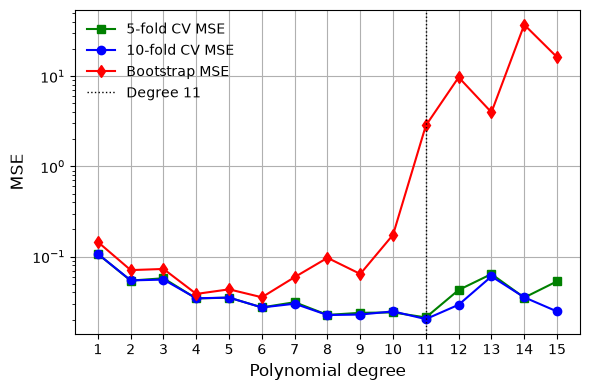

In [623]:
cv_mse5 = ols_k_fold(x,y, mx_degree, n_splits=5) #Compute CV MSE with 5 folds
cv_mse10 = ols_k_fold(x,y, mx_degree, n_splits=10) #Compute CV MSE with 10 folds
#Convert the inex of min CV MSE to degrees
best_deg5 = np.argmin(cv_mse5) + 1
best_deg10 = np.argmin(cv_mse10) + 1
#Print the degree an value selected by each CV
print(f"CV selects degree {best_deg5} (CV-MSE {cv_mse5[best_deg5-1]:.10f})")
print(f"CV selects degree {best_deg10} (CV-MSE {cv_mse10[best_deg10-1]:.10f})")
#Plot for the estemated MSE for OLS using 5-and 10-fold cross validation and bootstrap 
fig, ax = plt.subplots(figsize=(6.0, 4.0))
ax.plot(degrees, cv_mse5, "s-", color='g', label="5-fold CV MSE")
ax.plot(degrees, cv_mse10, "o-", color='b', label="10-fold CV MSE")
ax.plot(degrees, error, "d-", color = "r", label = "Bootstrap MSE ")

idx = int(np.argmin(cv_mse5))
best_degree = degrees[idx]
best_mse = cv_mse5[idx]

ax.axvline(best_degree, color = "k", ls=":", lw=1,label=f"Degree {best_degree}")
ax.set_xticks(np.arange(1, 16))
ax.set_yscale("log")
ax.grid()
ax.set_xlabel("Polynomial degree", fontsize = 12)
ax.set_ylabel(" MSE ", fontsize = 12)
ax.legend(frameon=False, fontsize = 10);plt.tight_layout()
plt.savefig("figures/OLS_BootCV.png", dpi=300, bbox_inches="tight")
plt.show()

In [624]:
sigma = 0.05 
#Compute CV validated MSE for 5 and 10 folds with a noise at 0.05
cv_mse5 = ols_k_fold(x, y, mx_degree, n_splits=5)
cv_mse10 = ols_k_fold(x, y, mx_degree, n_splits=10)
print(f"CV selects degree {best_deg5} (CV-MSE {cv_mse5[best_deg5-1]:.10f})")
print(f"CV selects degree {best_deg10} (CV-MSE {cv_mse10[best_deg10-1]:.10f})")

CV selects degree 11 (CV-MSE 0.0211129064)
CV selects degree 11 (CV-MSE 0.0202372654)


In [625]:
def RIDGE_k_fold(x, y, nlambdas, lambdas, k=5, degree=12):
    x = np.asarray(x).reshape(-1, 1) #Reshaping the data to use with sklearn
    y = np.asarray(y).ravel()
    
    mse_kr = np.zeros(nlambdas) #Initialize arrays for MSE and STD across folds
    std_kr = np.zeros(nlambdas)

    kfold = KFold(n_splits=k, shuffle=True, random_state=2026) #Define folds 
    # Number of training observations per fold for this evenly divisible dataset.
    
    for i, lmb in enumerate(lambdas): #Create polynomial feautures, standarize and fit Ridge
        pipe = make_pipeline(PolynomialFeatures(degree=degree), StandardScaler(), Ridge(alpha=lmb))
        scores = cross_val_score(pipe,x, y, cv = kfold, scoring="neg_mean_squared_error") #Compute negative validated MSE for each fold
        mse_kr[i] = np.mean(-scores) #Store positive value for the MSE
        std_kr[i] = scores.std() #Store STD
    return mse_kr, std_kr

In [626]:
ridge_tables = {} #Tabels for diffrent folds
nlam=100
for k in [5, 10]:
    rows = []
    for deg in degrees:
        mse, std = RIDGE_k_fold(x, y, nlam, lambdas, k=k, degree=deg) #Compute CV MSE and STD for each lambda
        best_j = np.argmin(mse)
        rows.append({"Degree": int(deg),"lambda": lambdas[best_j],"CV-MSE": mse[best_j],"Spread": std[best_j]})

    ridge_tables[k] = pd.DataFrame(rows)
    best_row = ridge_tables[k].loc[ridge_tables[k]["CV-MSE"].idxmin()]

In [627]:
display(ridge_tables[5].style.format({"lambda": "{:.4g}","CV-MSE": "{:.5f}","Spread": "{:.5f}"}).hide(axis="index"))
display(ridge_tables[10].style.format({"lambda": "{:.4g}","CV-MSE": "{:.5f}","Spread": "{:.5f}"}).hide(axis="index"))

Degree,lambda,CV-MSE,Spread
1,1,0.10668,0.02155
2,1,0.05409,0.01155
3,1,0.05693,0.01172
4,0.1072,0.03423,0.00746
5,0.2848,0.03452,0.00756
6,0.0231,0.02681,0.00426
7,0.04037,0.02763,0.00461
8,0.0005337,0.02240,0.00358
9,0.0006136,0.02315,0.00293
10,0.000115,0.02224,0.00267


Degree,lambda,CV-MSE,Spread
1,1,0.10690,0.03914
2,1,0.05437,0.02217
3,1,0.05533,0.02412
4,0.2154,0.03431,0.01243
5,0.3275,0.03456,0.01268
6,0.02656,0.02668,0.01150
7,0.04642,0.02734,0.01168
8,0.0003511,0.02240,0.00624
9,0.0005337,0.02228,0.00614
10,0.0001748,0.02185,0.00609


In [628]:
best5 = ridge_tables[5].loc[ridge_tables[5]["CV-MSE"].idxmin()]
best10 = ridge_tables[10].loc[ridge_tables[10]["CV-MSE"].idxmin()]

print(f"5-fold CV selects degree {int(best5['Degree'])}, "f"with lambda = {best5['lambda']:.4g}, "f"MSE = {best5['CV-MSE']:.5f}")
print(f"10-fold CV selects degree {int(best10['Degree'])}, "f"with lambda = {best10['lambda']:.4g}, "f"MSE = {best10['CV-MSE']:.5f}")

best_bootstrap = table_lambda.loc[table_lambda["Error"].idxmin()]
bootstrap_degree = int(best_bootstrap["Degree"])
bootstrap_lambda = best_bootstrap["Lambda"]
bootstrap_mse = best_bootstrap["Error"]
print(f"Bootsrap select degree:", bootstrap_degree ,"MSE estimate by bootsrap:",bootstrap_mse)

5-fold CV selects degree 12, with lambda = 1.874e-05, MSE = 0.02068
10-fold CV selects degree 12, with lambda = 1.072e-05, MSE = 0.01918
Bootsrap select degree: 6 MSE estimate by bootsrap: 0.029868903185618172


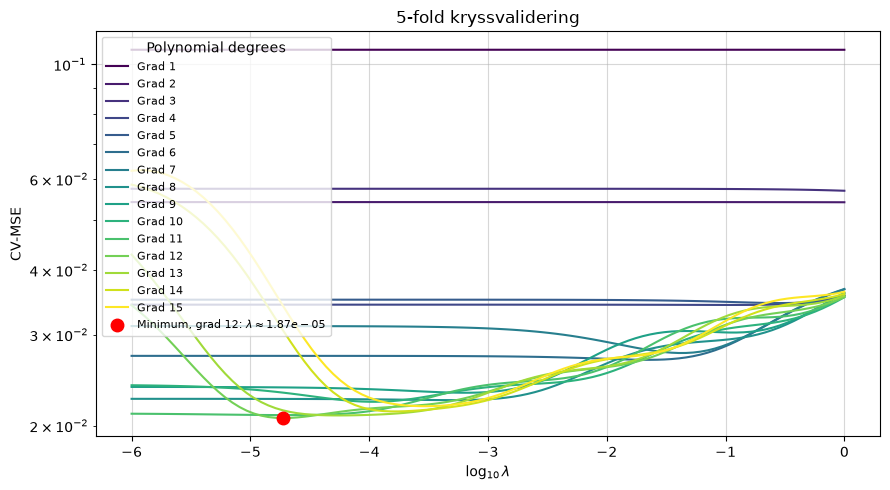

In [629]:
degrees = np.arange(1, 16)
fig, ax = plt.subplots(figsize=(9, 5))
colors = plt.cm.viridis(np.linspace(0, 1, len(degrees)))
for deg, color in zip(degrees, colors):
    mse, _ = RIDGE_k_fold(x, y, nlam, lambdas, k=5, degree=deg)
    if deg == 12:
        best5 = np.argmin(mse)
        best_lambda = lambdas[best5]
        best_mse = mse[best5]

    ax.plot(np.log10(lambdas), mse,color=color, lw=1.5, label=f"Grad {deg}")


ax.plot(np.log10(best_lambda), best_mse, "o", color="red", ms=9,label=rf"Minimum, grad 12: $\lambda\approx{best_lambda:.3g}$")

ax.set_title("5-fold kryssvalidering")
ax.set_xlabel(r"$\log_{10}\lambda$")
ax.set_ylabel("CV-MSE")
ax.set_yscale("log")
ax.grid(alpha=0.5)

ax.legend(title="Polynomial degrees", loc="upper left",fontsize=8)
plt.savefig("figures/Ridge_CV5.png", dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()

5-fold CV selects degree 12, with lambda = 1.874e-05, MSE = 0.02068
10-fold CV selects degree 12, with lambda = 1.072e-05, MSE = 0.01918
Bootstrap selects degree 6, with lambda = 0.04037, MSE = 0.02987


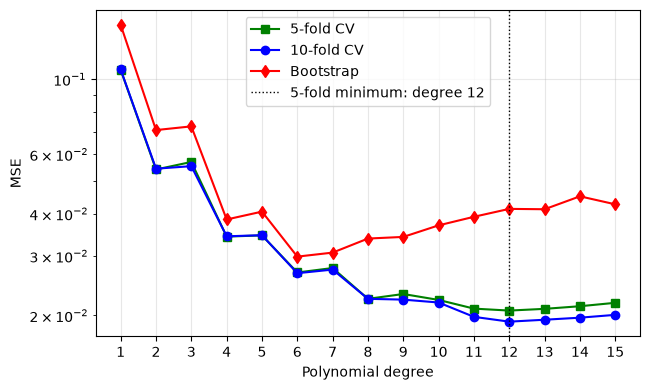

In [630]:
# Beste lambda for hver grad, for hver resamplingmetode
cv5 = (
    ridge_tables[5]
    .loc[ridge_tables[5].groupby("Degree")["CV-MSE"].idxmin()]
    .sort_values("Degree")
)
cv10 = (
    ridge_tables[10]
    .loc[ridge_tables[10].groupby("Degree")["CV-MSE"].idxmin()]
    .sort_values("Degree")
)
bootstrap_best = (
    table_lambda
    .loc[table_lambda.groupby("Degree")["Error"].idxmin()]
    .sort_values("Degree")
)

# Finn samlet minimum for hver metode
best5 = cv5.loc[cv5["CV-MSE"].idxmin()]
best10 = cv10.loc[cv10["CV-MSE"].idxmin()]
best_bootstrap = bootstrap_best.loc[bootstrap_best["Error"].idxmin()]

print(
    f"5-fold CV selects degree {int(best5['Degree'])}, "
    f"with lambda = {best5['lambda']:.4g}, "
    f"MSE = {best5['CV-MSE']:.5f}"
)
print(
    f"10-fold CV selects degree {int(best10['Degree'])}, "
    f"with lambda = {best10['lambda']:.4g}, "
    f"MSE = {best10['CV-MSE']:.5f}"
)
print(
    f"Bootstrap selects degree {int(best_bootstrap['Degree'])}, "
    f"with lambda = {best_bootstrap['Lambda']:.4g}, "
    f"MSE = {best_bootstrap['Error']:.5f}"
)

# Plot
fig, ax = plt.subplots(figsize=(6.6, 4.0))

ax.plot(
    cv5["Degree"], cv5["CV-MSE"],
    "s-", color="green", label="5-fold CV"
)
ax.plot(
    cv10["Degree"], cv10["CV-MSE"],
    "o-", color="blue", label="10-fold CV"
)
ax.plot(
    bootstrap_best["Degree"], bootstrap_best["Error"],
    "d-", color="red", label="Bootstrap"
)

best_degree = int(best5["Degree"])
best_mse = best5["CV-MSE"]

ax.axvline(
    best_degree, color="k", ls=":", lw=1,
    label=f"5-fold minimum: degree {best_degree}"
)


ax.set_xlabel("Polynomial degree")
ax.set_ylabel("MSE")
ax.set_xticks(sorted(cv5["Degree"].unique()))
ax.set_yscale("log")
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()

from pathlib import Path
Path("figures").mkdir(parents=True, exist_ok=True)

plt.savefig(
    "figures/Ridge_CVBootcompsigma.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [631]:
bootstrap_best = (table_lambda.loc[table_lambda2.groupby("Degree")["Error"].idxmin()].sort_values("Degree"))

CV for sigma = 0.05 for ridge

In [632]:
# Generate reproducible Runge data with noise standard deviation 0.05.
rng = np.random.default_rng(2026)
sigma = 0.05
n = 100
x = np.sort(rng.uniform(-1, 1, n))
y = runge(x) + rng.normal(0, sigma, size=n)

# Define the lambda grid and polynomial degrees.
lambdas = np.logspace(-6, 0, 100)
degrees = np.arange(1, 16)
nlam = len(lambdas)

# Store separate CV tables for noise level 0.05.
ridge_tables2 = {}

for k in [5, 10]:
    rows = []

    for d in degrees:
        # Compute CV-MSE and standard deviation across folds for each lambda.
        mse, std = RIDGE_k_fold(
            x, y, nlam, lambdas, k=k, degree=int(d)
        )

        # Select the lambda with the lowest CV-MSE for this degree.
        best_j = np.argmin(mse)

        rows.append({
            "Degree": int(d),
            "lambda": lambdas[best_j],
            "CV-MSE": mse[best_j],
            "Spread": std[best_j]
        })

    # Store and display the results for the current CV method.
    ridge_tables2[k] = pd.DataFrame(rows)

    display(
        ridge_tables2[k].style.format({
            "lambda": "{:.4g}",
            "CV-MSE": "{:.5f}",
            "Spread": "{:.5f}"
        }).hide(axis="index")
    )

    # Find the best degree–lambda combination.
    best_row = ridge_tables2[k].loc[
        ridge_tables2[k]["CV-MSE"].idxmin()
    ]

    print(
        f"{k}-fold CV, sigma={sigma}: "
        f"degree={int(best_row['Degree'])}, "
        f"lambda={best_row['lambda']:.4g}, "
        f"MSE={best_row['CV-MSE']:.6f}"
    )

# Extract CV results for subsequent plotting.
cv5_best_mse = ridge_tables2[5]["CV-MSE"].to_numpy()
cv10_best_mse = ridge_tables2[10]["CV-MSE"].to_numpy()
cv5_best_lambda = ridge_tables2[5]["lambda"].to_numpy()
cv10_best_lambda = ridge_tables2[10]["lambda"].to_numpy()

# Find the selected polynomial degree for each CV method.
i5 = np.argmin(cv5_best_mse)
best_degree5 = degrees[i5]
best_mse5 = cv5_best_mse[i5]

i10 = np.argmin(cv10_best_mse)
best_degree10 = degrees[i10]
best_mse10 = cv10_best_mse[i10]

# Select the bootstrap lambda with the lowest error for each degree.
bootstrap_best2 = (
    table_lambda2.loc[
        table_lambda2.groupby("Degree")["Error"].idxmin()
    ]
    .sort_values("Degree")
    .reset_index(drop=True)
)

Degree,lambda,CV-MSE,Spread
1,1,0.09767,0.01673
2,1,0.04575,0.00709
3,1,0.04704,0.00777
4,0.09326,0.02341,0.00541
5,0.3275,0.02400,0.00554
6,0.01748,0.01450,0.00252
7,0.03054,0.01499,0.00287
8,0.0008111,0.00897,0.00137
9,0.0009326,0.00915,0.00115
10,7.565e-05,0.00719,0.00139


5-fold CV, sigma=0.05: degree=12, lambda=8.111e-06, MSE=0.006305


Degree,lambda,CV-MSE,Spread
1,1,0.09768,0.02807
2,1,0.04566,0.01494
3,1,0.04609,0.01687
4,0.1874,0.02342,0.00861
5,0.3275,0.02377,0.00910
6,0.0231,0.01444,0.00627
7,0.03511,0.01482,0.00659
8,0.0007055,0.00879,0.00255
9,0.001072,0.00894,0.00274
10,0.0001,0.00714,0.00259


10-fold CV, sigma=0.05: degree=12, lambda=6.136e-06, MSE=0.005869


Diffrence of -16 is to MP.

4.5 (E and F) Gradient descent code, with analytical gradients and automatic differentiation
-

In [633]:
#NEW LIBRARY ABBREVIATIONS FOR LAST EXERCISES
import numpy as np
import matplotlib.pyplot as plt

In [634]:
# NEW FUNCTIONS USED FOR THE LAST EXERCISES

def runge(x):
    return 1.0 / (1.0 + 25.0 * x**2)
    

def make_data():
    '''Make runge data and return x and y'''
    rng = np.random.default_rng(2026)
    n = 100
    sigma = 0.1                                  
    x = np.sort(rng.uniform(-1, 1, n))
    y = runge(x) + rng.normal(0, sigma, n)
    return x, y, rng
    

def cf_ridge(X, y, lam=0.0):
    n, p = X.shape
    return np.linalg.pinv(X.T @ X + n * lam * np.eye(p)) @ X.T @ y
    

def cost_ridge(theta, X, y, lmbda):
    return np.mean((y - X @ theta)**2) + lmbda * np.sum(theta**2)
    

def analytic_grad_Ridge(theta, X, y, lmbda):
    return 2.0 / len(y) * X.T @ (X @ theta - y) + 2.0 * lmbda * theta
    

def design_standardized(x, y, degree, intercept=True):
    '''Make and standardize design matrix. Also return centered y data and its mean'''
    start = 0 if intercept else 1
    X = np.vstack([x**p for p in range(start, degree + 1)]).T
    X_mean, X_std = X.mean(axis=0), X.std(axis=0)
    X_std[X_std == 0] = 1
    X_norm = (X - X_mean) / X_std
    y_centered = y - y.mean()
    return X_norm, y_centered, y.mean()


def design_nonstandardized(x, degree, intercept=True):
    start = 0 if intercept else 1
    X = np.vstack([x**p for p in range(start, degree + 1)]).T
    return X


def optimiser_step(method, theta, g, state, t, gamma, beta=0.9, rho=0.99,
                   beta1=0.9, beta2=0.999, eps=1e-8):
    """One update of theta from the gradient g at step t = 1, 2, ...; state carries the running quantities."""
    if method == "plain":                                    # Eq. (4.10)
        return theta - gamma * g, state
    if method == "momentum":                                 # Eq. (4.28)
        v = beta*state.get("v", 0.0) + gamma*g
        state["v"] = v
        return theta - v, state
    if method == "adagrad":                                  # Eqs. (4.42) and (4.45)
        r = state.get("r", 0.0) + g*g
        state["r"] = r
        return theta - gamma * g / np.sqrt(eps + state.get("r", 0.0)), state
    if method == "rmsprop":                                  # Eqs. (4.47) and (4.48)
        r = rho*state.get("r", 0.0) + (1-rho)*g*g
        state["r"] = r
        return theta - gamma * g / np.sqrt(eps + state.get("r", 0.0)), state
    if method == "adam":                                     # Eqs. (4.51), (4.52), (4.54), (4.55)
        m = beta1*state.get("m", 0.0) + (1-beta1)*g
        r = beta2*state.get("r", 0.0) + (1-beta2)*g*g
        state["m"] = m 
        state["r"] = r
        m_hat, r_hat = m / (1-beta1**t), r / (1-beta2**t)
        return theta - gamma * m_hat / (np.sqrt(r_hat) + eps), state
    raise ValueError(f"unknown method {method}")


def optimise(grad, theta0, method, gamma, num_iters=1000, tol=0.0, upper_lim = 1e4, **kw):
    """Full-gradient loop; returns all iterates and the number of steps taken."""
    theta, state = np.array(theta0, dtype=float), {}
    history = [theta.copy()]
    for t in range(1, num_iters + 1):
        g = grad(theta)
        theta, state = optimiser_step(method, theta, g, state, t, gamma, **kw)
        history.append(theta.copy())
        if np.linalg.norm(g) > upper_lim:
            break
    return np.array(history)


def eigenvalues(X, lmbda):
    n, degree = np.shape(X)[0], np.shape(X)[1]
    H_Ridge = (2/n) * (X.T @ X) + 2*lmbda*np.eye(degree)
    Ridge_eigenvalues = np.linalg.eigvalsh(H_Ridge)
    eigmax = Ridge_eigenvalues[-1]
    eigmin = Ridge_eigenvalues[0]
    
    return eigmax, eigmin


def make_batches(n, batch_size, rng):
    """Shuffle the indices and split them into minibatches."""
    idx = rng.permutation(n)
    return [idx[i:i + batch_size] for i in range(0, n, batch_size)]


def step_length(t, t0, t1):
    """The schedule of Eq. (4.40)."""
    return t0 / (t + t1)


def sgd(X, y, method="plain", n_epochs=50, batch_size=5, gamma=0.1, schedule=None, lam=0.0, seed=2026, upper_lim=1e2, **kw):
    """Minibatch SGD, Eq. (4.34), with any optimiser. schedule=(t0, t1) replaces gamma by Eq. (4.40).
    Returns the iterate after every epoch."""
    rng = np.random.default_rng(seed)
    n, p = X.shape
    theta, state, t = np.zeros(p), {}, 0
    history = [theta.copy()]
    for epoch in range(n_epochs):
            for batch in make_batches(n, batch_size, rng):
                t += 1
                g = analytic_grad_Ridge(theta, X[batch, :], y[batch], lam)  #Analytic gradient used
                gamma_t =  gamma if schedule is None else step_length(t, *schedule) 
                theta, state = optimiser_step(method, theta, g, state, t, gamma_t, **kw)
            if np.linalg.norm(theta) > upper_lim:
                history_array = np.full((n_epochs + 1, p), np.nan)
                history_array[:len(history)] = np.array(history)
                return history_array
            else:
                history.append(theta.copy())
    return np.array(history)

In [635]:
degree = 5
lmbda = 1e-3

x, y, rng = make_data()
X5, y5, y5mean = design_standardized(x, y, degree, intercept=False)
theta5 = cf_ridge(X5, y5, lmbda)
c5 = cost_ridge(theta5, X5, y5, lmbda)
#grad5 = automatic_gradient(theta5, X5, y5, lam=lmbda)
grad5 = lambda th: analytic_grad_Ridge(th, X5, y5, lmbda)

gammas = np.geomspace(1e-3, 1.0, 16)
#np.seterr(over="ignore", invalid="ignore")   # diverging runs overflow; that is the answer, not an error
print("gamma grid:", np.round(gammas, 4))
scan = {}
scan_errors = {}
for method in ("plain", "momentum", "adagrad", "rmsprop", "adam"):
    its = []
    es = []
    for g in gammas:
        path = optimise(grad5, np.zeros(degree), method, g, num_iters=20000)
        e = np.array(np.abs([cost_ridge(p, X5, y5, lmbda) - c5 for p in path[::10]]))
        its.append(int(np.argmax(e < 1e-6)) * 10 if (e < 1e-6).any() else None)
        es.append(e[-1])
    scan[method] = its
    scan_errors[method] = es
    ok = [(gammas[i], its[i], es[i]) for i in range(len(its)) if its[i] is not None]
    best = min(ok, key=lambda t: t[1]) if ok else None
    print(f"{method:8s}: usable gamma from {ok[0][0]:.4f} to {ok[-1][0]:.4f}" if ok else f"{method:8s}: never reaches 1e-6",
          f"; best {best[1]} iterations at gamma = {best[0]:.3f}; final distance = {best[2]}" if best else "")

gamma grid: [0.001  0.0016 0.0025 0.004  0.0063 0.01   0.0158 0.0251 0.0398 0.0631
 0.1    0.1585 0.2512 0.3981 0.631  1.    ]
plain   : usable gamma from 0.0100 to 0.2512 ; best 680 iterations at gamma = 0.251; final distance = 6.938893903907228e-18
momentum: usable gamma from 0.0010 to 0.6310 ; best 110 iterations at gamma = 0.158; final distance = 6.938893903907228e-18
adagrad : usable gamma from 0.0100 to 1.0000 ; best 920 iterations at gamma = 0.063; final distance = 0.0
rmsprop : never reaches 1e-6 
adam    : usable gamma from 0.0010 to 1.0000 ; best 160 iterations at gamma = 0.025; final distance = 6.938893903907228e-18


In [636]:
eigmax_stand, eigmin_stand = eigenvalues(X5, lmbda)
X5_nonstand = design_nonstandardized(x, degree, intercept=False)
eigmax_nonstand, eigmin_nonstand = eigenvalues(X5_nonstand, lmbda)
gamma_max_stand = 2 / eigmax_stand
gamma_max_nonstand = 2 / eigmax_nonstand
kappa_stand = eigmax_stand / eigmin_stand
kappa_nonstand = eigmax_nonstand / eigmin_nonstand

In [637]:
print("eigmax_stand =", eigmax_stand)
print("gamma_max_stand =", gamma_max_stand)
print("kappa_stand =", kappa_stand)
print("eigmax_nonstand =", eigmax_nonstand)
print("gamma_max_nonstand =", gamma_max_nonstand)
print("kappa_nonstand =", kappa_nonstand)

eigmax_stand = 5.654736939256736
gamma_max_stand = 0.35368577203219675
kappa_stand = 439.5970287070854
eigmax_nonstand = 0.8789768057470753
gamma_max_nonstand = 2.2753728959891326
kappa_nonstand = 284.2359228304861


In [638]:
grad_ridge_ad = jax.grad(cost_ridge)
theta0 = rng.normal(size=X5.shape[1])

print("Ridge max |AD - analytic| =", np.max(np.abs(grad_ridge_ad(theta0, X5, y5, lmbda) - analytic_grad_Ridge(theta0, X5, y5, lmbda))))
print("Non-Scaled Ridge max |AD - analytic| =", np.max(np.abs(grad_ridge_ad(theta0, X5_nonstand, y, lmbda) - analytic_grad_Ridge(theta0, X5_nonstand, y, lmbda))))

Ridge max |AD - analytic| = 4.440892098500626e-16
Non-Scaled Ridge max |AD - analytic| = 5.551115123125783e-17


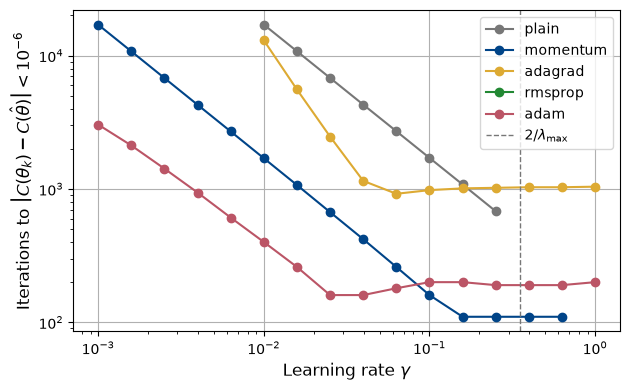

In [639]:
BLUE, RED, YELLOW, GREY, GREEN = "#004488", "#BB5566", "#DDAA33", "#777777", "#228833"

fig, ax = plt.subplots(figsize=(6.4, 4.0))
for method, col in (("plain", GREY), ("momentum", BLUE), ("adagrad", YELLOW), ("rmsprop", GREEN), ("adam", RED)):
    its = np.array([np.nan if k is None else k for k in scan[method]])
    ax.loglog(gammas, its, "o-", color=col, label=method)
ax.axvline(gamma_max_stand, color=GREY, ls="--", lw=1, label=r"$2/\lambda_{\max}$")
ax.set_xlabel(r"Learning rate $\gamma$", fontsize=12)
ax.set_ylabel(r"Iterations to $\left|C({\theta_{k}})-C(\hat{\theta})\right|<10^{-6}$", fontsize=12)
ax.legend(fontsize=10); fig.tight_layout()
ax.grid(True)
fig.savefig("figures/plot-task-f.png")
plt.show()

In [640]:
#import pandas as pd
from IPython.display import display, Math

In [641]:
rows_best = []

for method in scan:
    its = scan[method]
    errors = scan_errors[method]

    ok = [
        (gammas[i], its[i], errors[i])
        for i in range(len(gammas))
        if its[i] is not None
        and np.isfinite(errors[i])
    ]

    if ok:
        # Velg gammaen som når terskelen på færrest iterasjoner
        best_gamma, best_iterations, final_distance = min(
            ok,
            key=lambda row: row[1]
        )

        rows_best.append({
            "Method": method,
            "Best gamma": best_gamma,
            "Iterations": best_iterations,
            "Final distance": final_distance
        })
    else:
        rows_best.append({
            "Method": method,
            "Best gamma": None,
            "Iterations": None,
            "Final distance": None
        })

table_best = pd.DataFrame(rows_best)
display(table_best)

,Method,Best gamma,Iterations,Final distance
0,plain,0.251189,680.0,6.938894e-18
1,momentum,0.158489,110.0,6.938894e-18
2,adagrad,0.063096,920.0,0.000000e+00
3,rmsprop,NaN,NaN,NaN
4,adam,0.025119,160.0,6.938894e-18


In [642]:
grad_error_stand = np.max(
    np.abs(
        grad_ridge_ad(theta0, X5, y5, lmbda)
        - analytic_grad_Ridge(theta0, X5, y5, lmbda)
    )
)

grad_error_nonstand = np.max(
    np.abs(
        grad_ridge_ad(theta0, X5_nonstand, y, lmbda)
        - analytic_grad_Ridge(theta0, X5_nonstand, y, lmbda)
    )
)


table_values = {
    "lambda_max": (
        eigmax_stand,
        eigmax_nonstand
    ),
    "gamma_max": (
        gamma_max_stand,
        gamma_max_nonstand
    ),
    "kappa": (
        kappa_stand,
        kappa_nonstand
    ),
    "max gradient difference": (
        grad_error_stand,
        grad_error_nonstand
    )
}

headers = [
    r"\text{Quantity}",
    r"\text{Scaled}",
    r"\text{Non-scaled}"
]

lines = [
    r"\begin{array}{lrr}",
    " & ".join(headers) + r" \\ \hline"
]

rows = [
    (r"\lambda_{\max}", "lambda_max"),
    (r"\gamma_{\max}", "gamma_max"),
    (r"\kappa", "kappa"),
    (
        r"\max |\nabla C_{\mathrm{analytic}}"
        r"- \nabla C_{\mathrm{AD}}|",
        "max gradient difference"
    )
]

for label, key in rows:
    scaled, nonscaled = table_values[key]

    if key == "max gradient difference":
        scaled_fmt = f"{scaled:.2e}"
        nonscaled_fmt = f"{nonscaled:.2e}"
    else:
        scaled_fmt = f"{scaled:.3g}"
        nonscaled_fmt = f"{nonscaled:.3g}"

    lines.append(
        f"{label} & {scaled_fmt} & {nonscaled_fmt} \\\\"
    )

lines.append(r"\end{array}")

display(Math("\n".join(lines)))

<IPython.core.display.Math object>

G
-

In [643]:
def runge_data(n=100, degree=8, noise=0.1, seed=2026):

    rng = np.random.default_rng(seed)
    x = rng.uniform(-1.0, 1.0, n)
    y = 1.0 / (1.0 + 25.0 * x**2) + noise * rng.standard_normal(n)
    X = np.column_stack([x**k for k in range(1, degree + 1)])
    X_norm = (X - X.mean(axis=0)) / X.std(axis=0)
    return X_norm, y - y.mean()

def optimiser_step(method, theta, g, state, t, gamma, beta=0.9, rho=0.99,beta1=0.9, beta2=0.999, eps=1e-8):
    """One update of theta from the gradient g at step t = 1, 2, ...; state carries the running quantities."""
    if method == "plain":                                    # Eq. (4.10)
        return theta - gamma * g, state
    if method == "momentum":                                 # Eq. (4.28)
        state["v"] = v = beta * state.get("v", 0.0) + gamma * g 
        return theta - v, state
    if method == "adagrad":                                  # Eqs. (4.42) and (4.45)
        state["r"] = r = state.get("r", 0.0) + g * g
        return theta - gamma * g / (np.sqrt(r) + eps), state
    if method == "rmsprop":                                  # Eqs. (4.47) and (4.48)
        state["r"] = r = rho * state.get("r", 0.0) + (1.0 - rho) * g * g 
        return theta - gamma * g / (np.sqrt(r) + eps), state
    if method == "adam":                                     # Eqs. (4.51), (4.52), (4.54), (4.55)
        state["m"] = m =  beta1 * state.get("m", 0.0) + (1.0 - beta1) * g
        state["r"] = r = beta2 * state.get("r", 0.0) + (1.0 - beta2) * g * g
        m_hat, r_hat = m / (1.0 - beta1**t), r / (1.0 - beta2**t)
        return theta - gamma * m_hat / (np.sqrt(r_hat) + eps), state
    raise ValueError(f"unknown method {method}")

def optimise(grad, theta0, method, gamma, num_iters=1000, tol=1e-8, **kw):
    """Full-gradient loop; returns all iterates and the number of steps taken."""
    theta, state = np.array(theta0, dtype=float), {}
    
    history = [theta.copy()]
    for t in range(1, num_iters + 1):
        with np.errstate(over="ignore", invalid="ignore"):
            g = grad(theta)
        #g = grad(theta)
        if not np.all(np.isfinite(g)):
            break
        theta, state = optimiser_step(method, theta, g, state, t, gamma, **kw)
        if not np.all(np.isfinite(theta)):
            break

        history.append(theta.copy())
        if np.linalg.norm(g) < tol:
            break
    return np.array(history), t


def runge_comparison(runs, degree=10, num_iters=30000, tol_dist = 1e-8):
    """Excess cost C(theta_k) - C(theta_hat) for the five optimisers on the Runge problem."""
    X, y = runge_data(n=100, degree=degree, noise=0.1, seed=2026)#exercise_data(n=100, degree=degree, noise=0.5, seed=2026)    #Finne ut hvordan man skal gjre denne her.. 
    results = {}
    for lam in (0.0, 0.001):
        theta_cf = closed_form(X, y, lam)
        min_cost = cost(theta_cf, X,y,lam)
        grad = lambda theta: gradient(theta, X, y, lam)
        H = hessian(X, lam)
        eigenvalues = np.linalg.eigvalsh(H)
        lmax = eigenvalues.max()
        gamma_gd = 0.9 * 2.0 / lmax
        for method, gamma in runs:
            g = gamma_gd if gamma is None else gamma
            theta0 = np.zeros(X.shape[1])
            #path, steps = optimise(grad, theta0, method, g, num_iters=num_iters)
            path, steps = optimise(grad,theta0,method,g,num_iters=num_iters)
            distances = np.array([np.linalg.norm(theta_k - theta_cf) for theta_k in path])
            costs = np.array([cost(theta_k, X, y, lam)for theta_k in path])
            excess_cost = costs - min_cost
            results[(lam, method, g)] = {"distances": distances,"excess_cost": excess_cost, "final_cost": costs[-1],"steps": steps,"final_distance": distances[-1], "converged": distances[-1] < tol_dist}

    return results

In [644]:
runs = (("momentum", None),("adagrad", 0.001),("adagrad", 0.01),("adagrad", 0.1),("rmsprop", 0.001),("rmsprop", 0.01),("rmsprop", 0.1),("adam", 0.001), ("adam", 0.01), ("adam", 0.1))
results = runge_comparison(runs,degree=10,num_iters=10000, tol_dist = 1e-4)
headers = [r"\lambda", r"\text{Method}", r"\gamma",r"\text{Steps}", r"\text{Distance}", r"\text{Converged}"]
lines = [r"\begin{array}{rlrrrc}"," & ".join(headers) + r" \\ \hline"]

for (lam, method, gamma), result in results.items():
    values = [f"{lam:g}", rf"\text{{{method}}}", f"{gamma:.5f}", str(result["steps"]), f"{result['final_distance']:.3e}",
        r"\text{Yes}" if result["converged"] else r"\text{No}",]
    lines.append(" & ".join(values) + r" \\")

lines.append(r"\end{array}")
display(Math("\n".join(lines)))

<IPython.core.display.Math object>

In [645]:
import jax
import jax.numpy as jnp

derivative_at_zero = jax.grad(lambda t: jnp.abs(t))(0.0)

print("AD at zero:", derivative_at_zero)
print("My code at zero:", np.sign(0.0))

def lasso_gradient(theta, X, y, lam):
    n = len(y)
    mse_grad = (2 / n) * X.T @ (X @ theta - y)
    penalty_grad = lam * np.sign(theta)
    penalty_grad[0] = 0.0       # Ikke straff konstantleddet/interceptet

    return mse_grad + penalty_grad

degrees = 15
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=2026)


y_train = np.asarray(y_train).ravel()
y_test = np.asarray(y_test).ravel()
degree = 10
X_train = design_matrix(x_train, degree)
X_test = design_matrix(x_test, degree)
scaler = StandardScaler()
X_train_sc = X_train.copy()
X_test_sc = X_test.copy()
X_train_sc[:, 1:] = scaler.fit_transform(X_train[:, 1:])
X_test_sc[:, 1:] = scaler.transform(X_test[:, 1:])


lam = 0.001

grad_lasso = lambda theta: lasso_gradient(theta,X_train_sc,y_train,lam)
theta0 = np.zeros(X_train_sc.shape[1])

methods = ["momentum", "adagrad", "rmsprop", "adam"]


#optimaliseringsmetodene
for method in methods:
    gamma = 0.01


    theta_path, state = optimise(grad=grad_lasso,theta0=theta0.copy(), method=method, gamma=0.01, num_iters=10_000)
    theta_lasso = theta_path[-1]

    # Prediksjoner
    y_pred_train = X_train_sc @ theta_lasso
    y_pred_test = X_test_sc @ theta_lasso

    # MSE
    train_mse = np.mean((y_train - y_pred_train)**2)
    test_mse = np.mean((y_test - y_pred_test)**2)
    exact_zero = np.sum(theta_lasso[1:] == 0)
    near_zero = np.sum(np.abs(theta_lasso[1:]) < 1e-4)
    near_zero_degrees = np.where(np.abs(theta_lasso[1:]) < 1e-4)[0] + 1
    print(f"{method:8s}",f"train MSE: {train_mse:.6f}",f"test MSE: {test_mse:.6f}",f"exact zeros: {exact_zero}",f"near zeros: {near_zero}")
    
    #print(f"{method}, gamma={gamma}: "f"exact zeros={exact_zero}, near zeros={near_zero}")
    near_zero_degrees = np.where(np.abs(theta_lasso[1:]) < 1e-4)[0] + 1
    print("Grader med koeffisient nær null:", near_zero_degrees)
    #print("Verdiene:", theta_lasso[near_zero_degrees])

# Samme regulariseringsstyrke som i vår kostnadsfunksjon
alpha = lam / 2

# Vi fjerner konstantkolonnen fordi sklearn lager intercept selv
lasso_sklearn = Lasso( alpha=alpha, fit_intercept=True, max_iter=100_000, tol=1e-10)
lasso_sklearn.fit(X_train_sc[:, 1:],y_train)

# Samle intercept og koeffisienter i én theta-vektor
theta_sklearn = np.concatenate(([lasso_sklearn.intercept_],lasso_sklearn.coef_))
# Prediksjoner fra sklearn
y_pred_sklearn_train = lasso_sklearn.predict(X_train_sc[:, 1:])
y_pred_sklearn_test = lasso_sklearn.predict(X_test_sc[:, 1:])
# MSE
mse_sklearn_train = np.mean((y_train - y_pred_sklearn_train)**2)
mse_sklearn_test = np.mean((y_test - y_pred_sklearn_test)**2)
# Sammenlign med egen løsning
print("Egen theta:")
print(theta_lasso)

print("\nSklearn theta:")
print(theta_sklearn)

print("\nAvstand mellom koeffisientene:", np.linalg.norm(theta_lasso - theta_sklearn))
print("Sklearn train MSE:", mse_sklearn_train)
print("Sklearn test MSE:", mse_sklearn_test)
print("Adam test MSE", test_mse)
print("Adam train MSE", train_mse)

print( "Antall nuller i sklearn:", np.sum(theta_sklearn[1:] == 0))
print("Grader med eksakt null i sklearn:",np.flatnonzero(theta_sklearn[1:] == 0) + 1)



AD at zero: 1.0
My code at zero: 0.0
momentum train MSE: 0.024165 test MSE: 0.024261 exact zeros: 0 near zeros: 3
Grader med koeffisient nær null: [ 5  9 10]
adagrad  train MSE: 0.027292 test MSE: 0.030377 exact zeros: 0 near zeros: 2
Grader med koeffisient nær null: [5 7]
rmsprop  train MSE: 0.024558 test MSE: 0.022792 exact zeros: 0 near zeros: 1
Grader med koeffisient nær null: [5]
adam     train MSE: 0.023032 test MSE: 0.022577 exact zeros: 0 near zeros: 0
Grader med koeffisient nær null: []
Egen theta:
[ 3.73605431e-01 -1.18102373e-02 -1.12574456e+00  1.96882629e-02
  1.77853357e+00  6.28171214e-04 -8.83266274e-01 -1.55643470e-02
 -1.43391962e-03 -6.72671547e-04  1.88802552e-04]

Sklearn theta:
[ 0.37360543 -0.01200488 -1.12458024  0.01935675  1.77667143 -0.
 -0.88191747 -0.01687599 -0.         -0.          0.        ]

Avstand mellom koeffisientene: 0.0033837181420495748
Sklearn train MSE: 0.023028440969369773
Sklearn test MSE: 0.022725703658365237
Adam test MSE 0.022576922775272

In [646]:
def lasso_cost(theta):
    return (np.mean((y_train - X_train_sc @ theta)**2)+ lam * np.sum(np.abs(theta[1:])))

print("Adam Lasso cost:", lasso_cost(theta_lasso))
print("Sklearn Lasso cost:", lasso_cost(theta_sklearn))

lam = 0.001
grad_lasso = lambda theta: lasso_gradient(theta,X_train_sc,y_train,lam)
theta0 = np.zeros(X_train_sc.shape[1])

methods = ["momentum", "adagrad", "rmsprop", "adam"]
gammas = [0.0001, 0.001, 0.01, 0.1]

results = {}

for method in methods:
    results[method] = {}

    for gamma in gammas:

        theta_path, state = optimise(grad=grad_lasso,theta0=theta0.copy(),method=method,gamma=gamma,num_iters=10_000)

        theta_lasso = theta_path[-1]

        # Kontroller om metoden divergerte
        if not np.all(np.isfinite(theta_lasso)):
            results[method][gamma] = {"train_mse": np.nan,"test_mse": np.nan,"near_zero": 0,"diverged": True}

            print(f"{method:8s}, gamma={gamma}: divergerte")
            continue

        # Prediksjoner
        y_pred_train = X_train_sc @ theta_lasso
        y_pred_test = X_test_sc @ theta_lasso

        # MSE
        train_mse = np.mean((y_train - y_pred_train)**2)

        test_mse = np.mean((y_test - y_pred_test)**2)

        coefficients = theta_lasso[1:]

        results[method][gamma] = {
            "train_mse": train_mse,
            "test_mse": test_mse,
            "cost": train_mse + lam * np.sum(np.abs(coefficients)),
            "exact_zero": np.sum(coefficients == 0),
            "near_zero": np.sum(np.abs(coefficients) < 1e-4),
            "diverged": False,
            "theta": theta_lasso.copy()}


rows = []

for method, gamma_results in results.items():
    for gamma, result in gamma_results.items():
        if result["diverged"]:
            continue

        rows.append({
            "Optimizer": method,
            "Gamma": gamma,
            "Test MSE": result["test_mse"],
            "Lasso cost": result["cost"],
            "Exact zeros": result["exact_zero"],
            "Near zeros": result["near_zero"] })



Adam Lasso cost: 0.02686926472871975
Sklearn Lasso cost: 0.026859847719173085


In [647]:
table = (pd.DataFrame(rows).sort_values("Test MSE").reset_index(drop=True))

print("Alle kombinasjoner, sortert etter test-MSE:")
display(table.round(6))

# Første rad for hver optimizer har dens laveste test-MSE
best_per_optimizer = table.drop_duplicates("Optimizer")

print("\nBeste læringsrate for hver optimizer:")
#display(best_per_optimizer.round(5))

# Velg kombinasjonen med lavest test-MSE
best = table.iloc[0]
best_method = best["Optimizer"]
best_gamma = float(best["Gamma"])

theta_best = results[best_method][best_gamma]["theta"].copy()

print(f"\nLavest test-MSE: {best_method}, gamma={best_gamma:g}")
print(f"Test MSE: {best['Test MSE']:.8f}")
print(f"Lasso cost: {best['Lasso cost']:.8f}")

best_cost = table.sort_values("Lasso cost").iloc[0]
best_methodL = best_cost["Optimizer"]
best_gammaL = float(best_cost["Gamma"])
theta_bestL = results[best_methodL][best_gammaL]["theta"].copy()

print("Valgt optimizer:", best_methodL)
print("Gamma:", best_gammaL)

# Velg Adam-kjøringen med lavest Lasso-kostnad
best_adam = (table[table["Optimizer"] == "adam"].sort_values("Lasso cost").iloc[0])

gamma_adam = float(best_adam["Gamma"])
theta_adam = results["adam"][gamma_adam]["theta"].copy()

# Scikit-learn med samme regulariseringsstyrke
alpha = lam / 2

lasso_sklearn = Lasso(alpha=alpha,fit_intercept=True,max_iter=100_000,tol=1e-10)
lasso_sklearn.fit(X_train_sc[:, 1:], y_train)

theta_sklearn = np.concatenate(([lasso_sklearn.intercept_], lasso_sklearn.coef_))

# Prediksjoner og MSE
y_pred_sklearn_train = lasso_sklearn.predict(X_train_sc[:, 1:])
y_pred_sklearn_test = lasso_sklearn.predict(X_test_sc[:, 1:])

mse_sklearn_train = np.mean((y_train - y_pred_sklearn_train)**2)
mse_sklearn_test = np.mean((y_test - y_pred_sklearn_test)**2)

Alle kombinasjoner, sortert etter test-MSE:


,Optimizer,Gamma,Test MSE,Lasso cost,Exact zeros,Near zeros
0,adam,0.0100,0.022577,0.026869,0,0
1,momentum,0.1000,0.022740,0.026860,0,1
2,rmsprop,0.0100,0.022792,0.027629,0,1
3,adam,0.0010,0.022819,0.026861,0,2
4,rmsprop,0.0010,0.023803,0.027020,0,1
5,adagrad,0.1000,0.024198,0.027030,0,3
6,adam,0.1000,0.024220,0.027426,0,0
7,momentum,0.0100,0.024261,0.027037,0,3
8,rmsprop,0.0001,0.028774,0.028922,0,1
9,momentum,0.0010,0.029878,0.028881,0,2



Beste læringsrate for hver optimizer:

Lavest test-MSE: adam, gamma=0.01
Test MSE: 0.02257692
Lasso cost: 0.02686926
Valgt optimizer: momentum
Gamma: 0.1


In [648]:
# Sammenligning
print("Adam gamma:", gamma_adam)

print("\nAdam theta:")
print(theta_adam)

print("\nSklearn theta:")
print(theta_sklearn)

print("\nAvstand mellom koeffisientene:", np.linalg.norm(theta_adam - theta_sklearn))

print("\nAdam train MSE:", results["adam"][gamma_adam]["train_mse"])
print("Sklearn train MSE:", mse_sklearn_train)
print("Adam test MSE:", best_adam["Test MSE"])
print("Sklearn test MSE:", mse_sklearn_test)

print("\nAdam Lasso cost:", lasso_cost(theta_adam))
print("Sklearn Lasso cost:", lasso_cost(theta_sklearn))

print("\nAntall eksakte nuller i Adam:",np.sum(theta_adam[1:] == 0))
print("Antall eksakte nuller i sklearn:",np.sum(theta_sklearn[1:] == 0))

print("\nGrader med eksakt null i Adam:", np.flatnonzero(theta_adam[1:] == 0) + 1)
print("Grader med eksakt null i sklearn:", np.flatnonzero(theta_sklearn[1:] == 0) + 1)


Adam gamma: 0.001

Adam theta:
[ 3.73605431e-01 -1.25347809e-02 -1.11780335e+00  2.07374366e-02
  1.75762864e+00  3.70681797e-05 -8.69328035e-01 -1.74586060e-02
 -3.65239879e-04 -9.63362591e-06  1.90109148e-04]

Sklearn theta:
[ 0.37360543 -0.01200488 -1.12458024  0.01935675  1.77667143 -0.
 -0.88191747 -0.01687599 -0.         -0.          0.        ]

Avstand mellom koeffisientene: 0.023869342809636093

Adam train MSE: 0.023064885810454325
Sklearn train MSE: 0.023028440969369773
Adam test MSE: 0.022818944369039383
Sklearn test MSE: 0.022725703658365237

Adam Lasso cost: 0.02686097870988409
Sklearn Lasso cost: 0.026859847719173085

Antall eksakte nuller i Adam: 0
Antall eksakte nuller i sklearn: 4

Grader med eksakt null i Adam: []
Grader med eksakt null i sklearn: [ 5  8  9 10]


OLS    train MSE = 0.018023 test MSE = 0.021394 ||theta||₁ = 17.0344 ||theta||₂ = 6.4381 near zero = 0
Ridge  train MSE = 0.030117 test MSE = 0.037857 ||theta||₁ = 1.3427 ||theta||₂ = 0.6892 near zero = 0
Lasso  train MSE = 0.031381 test MSE = 0.039489 ||theta||₁ = 0.9298 ||theta||₂ = 0.6608 near zero = 3


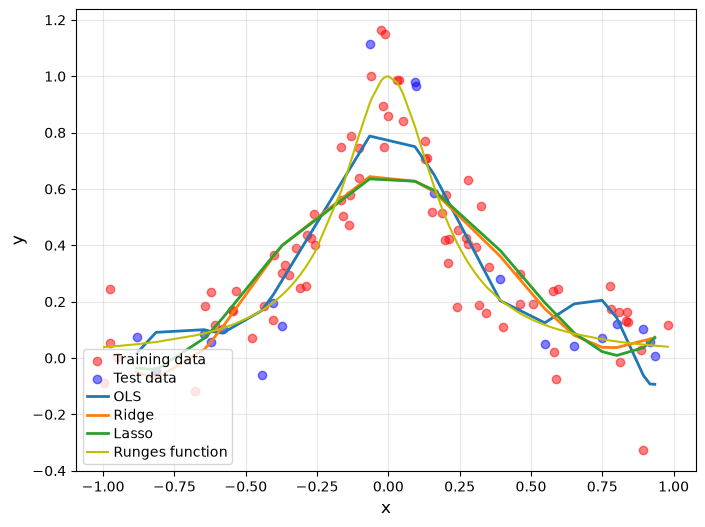

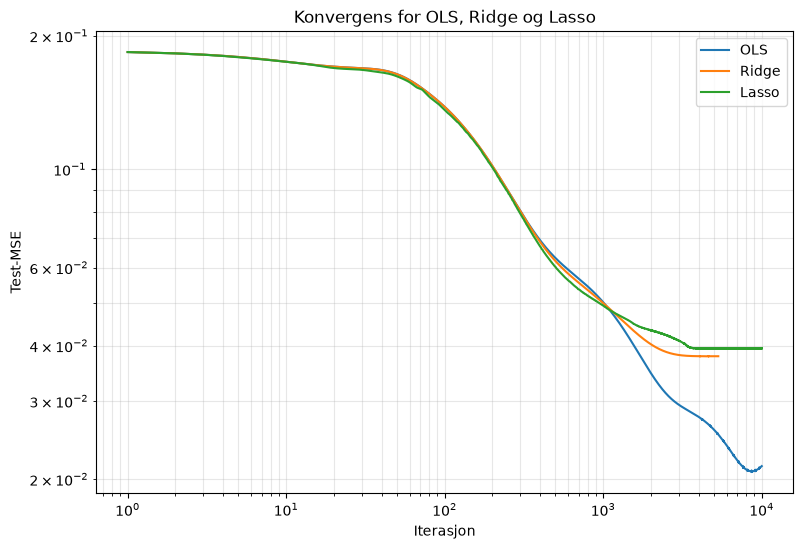

In [649]:
lam_ridge = 0.01
lam_lasso = 0.01

gamma = 0.001
method = "adam"
num_iters = 10_000

theta0 = np.zeros(X_train_sc.shape[1])

gradient_functions = {
    "OLS": lambda theta: gradient(theta, X_train_sc, y_train, lam=0.0),
    "Ridge": lambda theta: gradient(theta, X_train_sc, y_train, lam=lam_ridge),
    "Lasso": lambda theta: lasso_gradient(theta, X_train_sc, y_train, lam=lam_lasso)}

results_models = {}

for model_name, grad_function in gradient_functions.items():

    theta_path, state = optimise(grad=grad_function,theta0=theta0.copy(),method=method,gamma=gamma,num_iters=num_iters)
    theta = theta_path[-1]

    y_pred_train = X_train_sc @ theta
    y_pred_test = X_test_sc @ theta

    train_mse = np.mean((y_train - y_pred_train)**2)
    test_mse = np.mean((y_test - y_pred_test)**2)

    results_models[model_name] = {"theta": theta,"theta_path": theta_path,"train_mse": train_mse,"test_mse": test_mse}
    print(f"{model_name:6s}",f"train MSE = {train_mse:.6f}",f"test MSE = {test_mse:.6f}",f"||theta||₁ = {np.sum(np.abs(theta[1:])):.4f}",f"||theta||₂ = {np.linalg.norm(theta[1:]):.4f}",f"near zero = {np.sum(np.abs(theta[1:]) < 1e-4)}")

sort_idx = np.argsort(np.asarray(x_test).ravel())
x_test_sorted = np.asarray(x_test).ravel()[sort_idx]
y_test_sorted = np.asarray(y_test).ravel()[sort_idx]

plt.figure(figsize=(8, 6))
plt.scatter(x_train,y_train,alpha=0.5, color = "r",label="Training data")
plt.scatter(x_test,y_test,alpha=0.5,color = "b", label="Test data")
for model_name, result in results_models.items():
    y_pred_sorted = (X_test_sc @ result["theta"])[sort_idx]
    plt.plot(x_test_sorted,y_pred_sorted,linewidth=2,label=model_name)
plt.plot(x,runge(x), color = "y", label = "Runges function")
plt.xlabel("x", fontsize = 12)
plt.ylabel("y", fontsize = 12)
plt.legend(loc="lower left",fontsize=10,borderpad=0.3,labelspacing=0.3,handlelength=1.5,handletextpad=0.4)

plt.savefig("figures/RidgeLassoOLScomp.png", dpi=300, bbox_inches="tight")

plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(9, 6))

for model_name, result in results_models.items():

    theta_path = np.asarray(result["theta_path"])
    test_mse_history = []

    for theta in theta_path:
        y_pred_test = X_test_sc @ theta
        mse = np.mean((y_test - y_pred_test)**2)
        test_mse_history.append(mse)

    iterations = np.arange(1, len(theta_path) + 1)
    plt.loglog(iterations,test_mse_history,label=model_name)

plt.xlabel("Iterasjon")
plt.ylabel("Test-MSE")
plt.title("Konvergens for OLS, Ridge og Lasso")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.savefig("figures/Convergencecomp.png", dpi=300, bbox_inches="tight")

plt.show()

H Stocastic gradient decent
-

In [650]:
x, y, rng = make_data()
degree = 5
lmbda = 0.0
X5, y5, y5mean = design_standardized(x, y, degree, intercept=False)
theta_cf = cf_ridge(X5, y5, lmbda)
cost_cf = cost_ridge(theta_cf, X5, y5, lmbda)

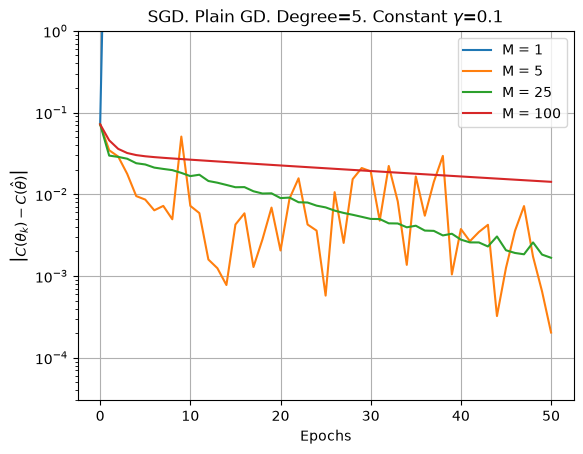

In [651]:
gamma = 0.1
Ms = np.array([1, 5, 25, len(y5)])

for M in Ms:
    thetas = sgd(X5, y5, batch_size=M, gamma=gamma)
    excess_mse = np.array([cost_ridge(theta, X5, y5, lmbda) - cost_cf for theta in thetas])

    plt.plot(range(len(excess_mse)), excess_mse, label=f"M = {M}")

plt.yscale("log")
plt.grid(True)
plt.ylim(3e-5, 1)
plt.xlabel("Epochs")
plt.ylabel(r"$\left|C({\theta_{k}})-C(\hat{\theta})\right|$")
plt.title(f"SGD. Plain GD. Degree={degree}. Constant $\\gamma$={gamma}")
plt.legend()
plt.savefig("figures/plot-h1-pla.png", bbox_inches="tight")
plt.show()

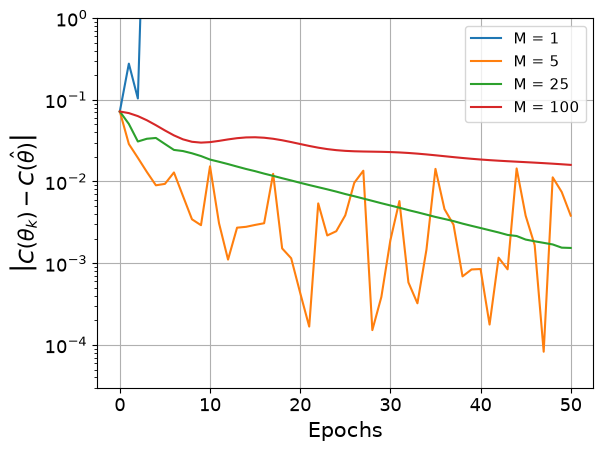

In [652]:
method = "momentum"
gamma = 0.01

for M in Ms:
    thetas = sgd(X5, y5, method=method, batch_size=M, gamma=gamma)
    excess_mse = np.array([cost_ridge(theta, X5, y5, 0.0) - cost_cf for theta in thetas])

    plt.plot(range(len(excess_mse)), excess_mse, label=f"M = {M}")

plt.yscale("log")
plt.ylim(3e-5, 1)
plt.xlabel("Epochs", fontsize=15)
plt.ylabel(r"$\left|C({\theta_{k}})-C(\hat{\theta})\right|$", fontsize=15)
#plt.title(f"SGD. {method}. Degree={degree}. Constant $\\gamma$={gamma}")
plt.legend(fontsize=11)
plt.grid(True)
plt.tick_params(axis="both", which="major", labelsize=13)
plt.savefig("figures/plot-h2-mom.png", bbox_inches="tight")
plt.show()

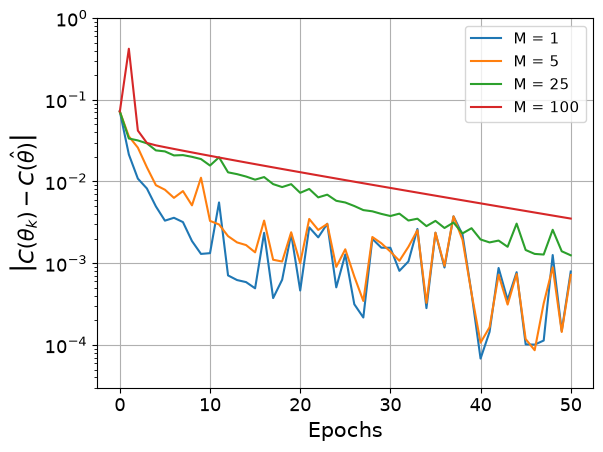

In [653]:
method = "adagrad"
gamma = 0.2

for M in Ms:
    thetas = sgd(X5, y5, method=method, batch_size=M, gamma=gamma)
    excess_mse = np.array([cost_ridge(theta, X5, y5, 0.0) - cost_cf for theta in thetas])

    plt.plot(range(len(excess_mse)), excess_mse, label=f"M = {M}")

plt.yscale("log")
plt.ylim(3e-5, 1)
plt.xlabel("Epochs", fontsize=15)
plt.ylabel(r"$\left|C({\theta_{k}})-C(\hat{\theta})\right|$", fontsize=15)
#plt.title(f"SGD. {method}. Degree={degree}. Constant $\\gamma$={gamma}")
plt.legend(fontsize=11)
plt.grid(True)
plt.tick_params(axis="both", which="major", labelsize=13)
plt.savefig("figures/plot-h3-adag.png", bbox_inches="tight")
plt.show()

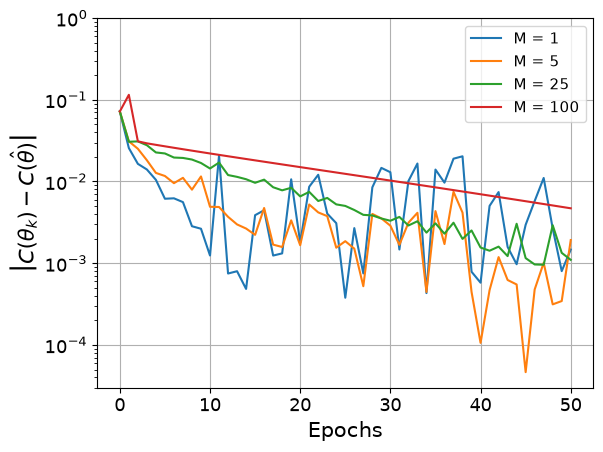

In [654]:
method = "rmsprop"
gamma = 0.01

for M in Ms:
    thetas = sgd(X5, y5, method=method, batch_size=M, gamma=gamma)
    excess_mse = np.array([cost_ridge(theta, X5, y5, 0.0) - cost_cf for theta in thetas])

    plt.plot(range(len(excess_mse)), excess_mse, label=f"M = {M}")

plt.yscale("log")
plt.ylim(3e-5, 1)
plt.xlabel("Epochs", fontsize=15)
plt.ylabel(r"$\left|C({\theta_{k}})-C(\hat{\theta})\right|$", fontsize=15)
#plt.title(f"SGD. {method}. Degree={degree}. Constant $\\gamma$={gamma}")
plt.legend(fontsize=11)
plt.grid(True)
plt.tick_params(axis="both", which="major", labelsize=13)
plt.savefig("figures/plot-h4-rms.png", bbox_inches="tight")
plt.show()

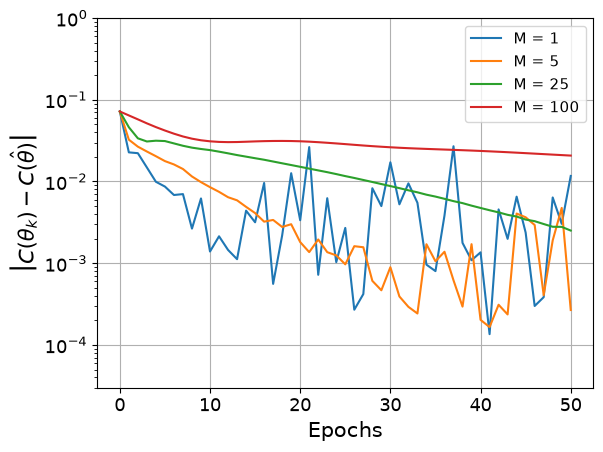

In [655]:
method = "adam"
gamma = 0.01

for M in Ms:
    thetas = sgd(X5, y5, method=method, batch_size=M, gamma=gamma)
    excess_mse = np.array([cost_ridge(theta, X5, y5, 0.0) - cost_cf for theta in thetas])

    plt.plot(range(len(excess_mse)), excess_mse, label=f"M = {M}")

plt.yscale("log")
plt.ylim(3e-5, 1)
plt.xlabel("Epochs", fontsize=15)
plt.ylabel(r"$\left|C({\theta_{k}})-C(\hat{\theta})\right|$", fontsize=15)
#plt.title(f"SGD. {method}. Degree={degree}. Constant $\\gamma$={gamma}")
plt.legend(fontsize=11)
plt.grid(True)
plt.tick_params(axis="both", which="major", labelsize=13)
plt.savefig("figures/plot-h5-adam.png", bbox_inches="tight")
plt.show()

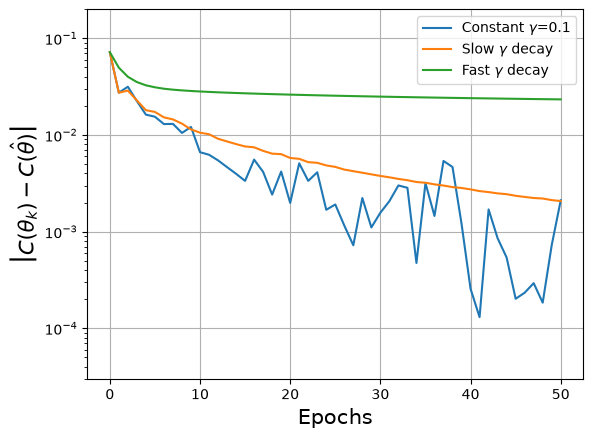

In [656]:
M = 10
method = "plain"
gamma = 0.1
schedules = [(100*gamma, 100.0), (10*gamma, 100.0)]

#for constant gamma
thetas = sgd(X5, y5, method=method, batch_size=M, gamma=gamma)
excess_mse = np.array([cost_ridge(theta, X5, y5, 0.0) - cost_cf for theta in thetas])
plt.plot(range(len(excess_mse)), excess_mse, label=f"Constant $\\gamma$={gamma}")

#for schedules
fast = False
for schedule in schedules:
    thetas = sgd(X5, y5, method=method, batch_size=M, schedule=schedule)
    excess_mse = np.array([cost_ridge(theta, X5, y5, 0.0) - cost_cf for theta in thetas])
    plt.plot(range(len(excess_mse)), excess_mse, label="Fast $\gamma$ decay" if fast else "Slow $\gamma$ decay")
    fast = True

plt.yscale("log")
plt.xlabel("Epochs", fontsize=15)
plt.ylabel(r"$\left|C({\theta_{k}})-C(\hat{\theta})\right|$", fontsize=15)
plt.ylim(3e-5, 2e-1)
#plt.title(f"SGD. {method}. Degree={degree}. M = {M}")
plt.legend()
plt.grid(True)
plt.savefig("figures/plot-h6-pla.png", bbox_inches="tight")
plt.show()

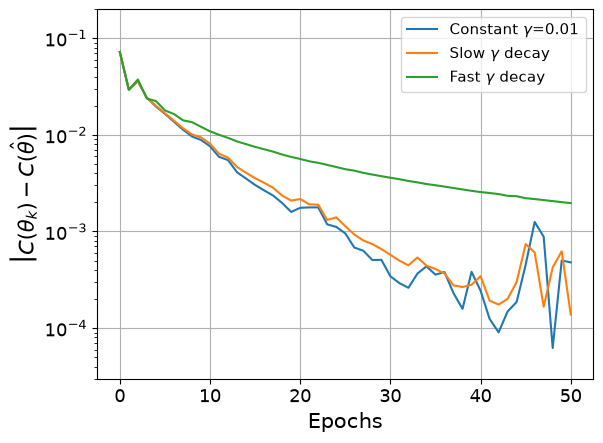

In [657]:
method = "momentum"
gamma = 0.01
schedules = [(1000*gamma, 1000.0), (100*gamma, 100.0)]

#for constant gamma
thetas = sgd(X5, y5, method=method, batch_size=M, gamma=gamma)
excess_mse = np.array([cost_ridge(theta, X5, y5, 0.0) - cost_cf for theta in thetas])
plt.plot(range(len(excess_mse)), excess_mse, label=f"Constant $\\gamma$={gamma}")

#for schedules
fast = False
for schedule in schedules:
    thetas = sgd(X5, y5, method=method, batch_size=M, schedule=schedule)
    excess_mse = np.array([cost_ridge(theta, X5, y5, 0.0) - cost_cf for theta in thetas])
    plt.plot(range(len(excess_mse)), excess_mse, label="Fast $\gamma$ decay" if fast else "Slow $\gamma$ decay")
    fast = True

plt.yscale("log")
plt.xlabel("Epochs", fontsize=15)
plt.ylabel(r"$\left|C({\theta_{k}})-C(\hat{\theta})\right|$", fontsize=15)
plt.ylim(3e-5, 2e-1)
#plt.title(f"SGD. {method}. Degree={degree}. M = {M}")
plt.legend(fontsize=11)
plt.grid(True)
plt.tick_params(axis="both", which="major", labelsize=13)
plt.savefig("figures/plot-h7-mom.png", bbox_inches="tight")
plt.show()

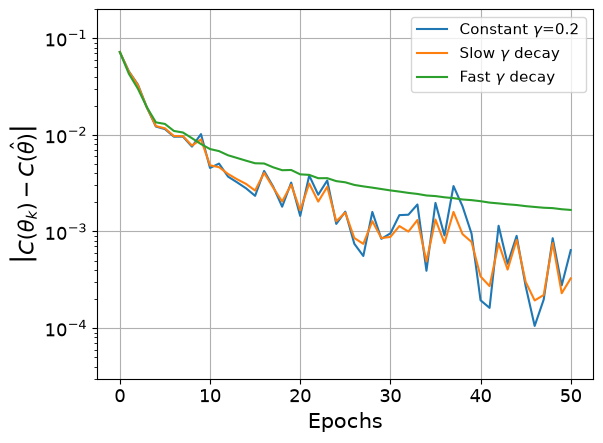

In [658]:
method = "adagrad"
gamma = 0.2
schedules = [(1000*gamma, 1000.0), (100*gamma, 100.0)]

#for constant gamma
thetas = sgd(X5, y5, method=method, batch_size=M, gamma=gamma)
excess_mse = np.array([cost_ridge(theta, X5, y5, 0.0) - cost_cf for theta in thetas])
plt.plot(range(len(excess_mse)), excess_mse, label=f"Constant $\\gamma$={gamma}")

#for schedules
fast = False
for schedule in schedules:
    thetas = sgd(X5, y5, method=method, batch_size=M, schedule=schedule)
    excess_mse = np.array([cost_ridge(theta, X5, y5, 0.0) - cost_cf for theta in thetas])
    plt.plot(range(len(excess_mse)), excess_mse, label="Fast $\gamma$ decay" if fast else "Slow $\gamma$ decay")
    fast = True

plt.yscale("log")
plt.xlabel("Epochs", fontsize=15)
plt.ylabel(r"$\left|C({\theta_{k}})-C(\hat{\theta})\right|$", fontsize=15)
plt.ylim(3e-5, 2e-1)
#plt.title(f"SGD. {method}. Degree={degree}. M = {M}")
plt.legend(fontsize=11)
plt.grid(True)
plt.tick_params(axis="both", which="major", labelsize=13)
plt.savefig("figures/plot-h8-adag.png", bbox_inches="tight")
plt.show()

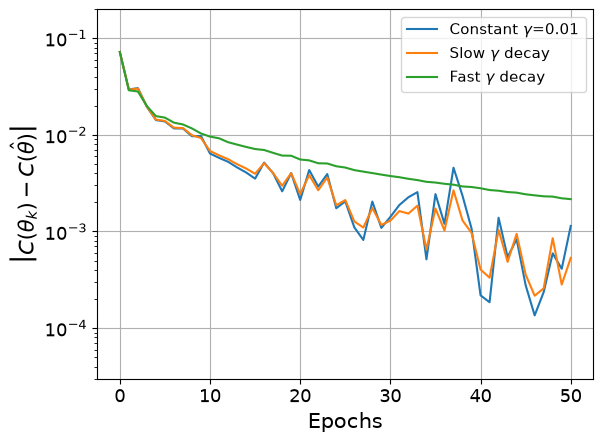

In [659]:
method = "rmsprop"
gamma = 0.01
schedules = [(1000*gamma, 1000.0), (100*gamma, 100.0)]

#for constant gamma
thetas = sgd(X5, y5, method=method, batch_size=M, gamma=gamma)
excess_mse = np.array([cost_ridge(theta, X5, y5, 0.0) - cost_cf for theta in thetas])
plt.plot(range(len(excess_mse)), excess_mse, label=f"Constant $\\gamma$={gamma}")

#for schedules
fast = False
for schedule in schedules:
    thetas = sgd(X5, y5, method=method, batch_size=M, schedule=schedule)
    excess_mse = np.array([cost_ridge(theta, X5, y5, 0.0) - cost_cf for theta in thetas])
    plt.plot(range(len(excess_mse)), excess_mse, label="Fast $\gamma$ decay" if fast else "Slow $\gamma$ decay")
    fast = True

plt.yscale("log")
plt.xlabel("Epochs", fontsize=15)
plt.ylabel(r"$\left|C({\theta_{k}})-C(\hat{\theta})\right|$", fontsize=15)
plt.ylim(3e-5, 2e-1)
#plt.title(f"SGD. {method}. Degree={degree}. M = {M}")
plt.legend(fontsize=11)
plt.grid(True)
plt.tick_params(axis="both", which="major", labelsize=13)
plt.savefig("figures/plot-h9-rms.png", bbox_inches="tight")
plt.show()

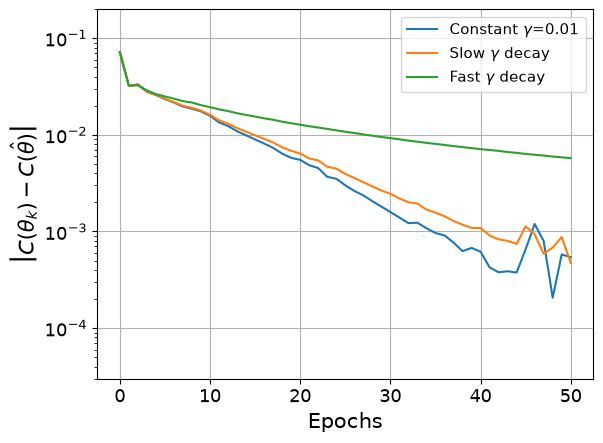

In [660]:
method = "adam"
gamma = 0.01
schedules = [(1000*gamma, 1000.0), (100*gamma, 100.0)]

#for constant gamma
thetas = sgd(X5, y5, method=method, n_epochs=50, batch_size=M, gamma=gamma)
excess_mse = np.array([cost_ridge(theta, X5, y5, 0.0) - cost_cf for theta in thetas])
plt.plot(range(len(excess_mse)), excess_mse, label=f"Constant $\\gamma$={gamma}")

#for schedules
fast = False
for schedule in schedules:
    thetas = sgd(X5, y5, method=method, n_epochs=50, batch_size=M, schedule=schedule)
    excess_mse = np.array([cost_ridge(theta, X5, y5, 0.0) - cost_cf for theta in thetas])
    plt.plot(range(len(excess_mse)), excess_mse, label="Fast $\gamma$ decay" if fast else "Slow $\gamma$ decay")
    fast = True

plt.yscale("log")
plt.xlabel("Epochs", fontsize=15)
plt.ylabel(r"$\left|C({\theta_{k}})-C(\hat{\theta})\right|$", fontsize=15)
plt.ylim(3e-5, 2e-1)
#plt.title(f"SGD. {method}. Degree={degree}. M = {M}")
plt.legend(fontsize=11)
plt.grid(True)
plt.tick_params(axis="both", which="major", labelsize=13)
plt.savefig("figures/plot-h10-adam.png", bbox_inches="tight")
plt.show()

I
-

In [661]:
degrees = np.arange(1, 16)
lambdas = np.logspace(-6, 0, 100)

rng = np.random.default_rng(2026)
sigma = 0.1
n = 100
x = np.sort(rng.uniform(-1,1,n))
y = runge(x) + rng.normal(0, sigma, size = n)    
x = np.asarray(x).reshape(-1, 1)
y = np.asarray(y).ravel()


kf = KFold(n_splits=5, shuffle=True, random_state=2026)
# OLS
ols_mse = np.zeros(len(degrees))
ols_std = np.zeros(len(degrees))
#Ridge
ridge_mse = np.zeros((len(degrees), len(lambdas)))
ridge_std = np.zeros((len(degrees), len(lambdas)))
#Lasso
lasso_mse = np.zeros((len(degrees), len(lambdas)))
lasso_std = np.zeros((len(degrees), len(lambdas)))

#

for i, degree in enumerate(degrees):
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    #OLS
    ols_pipe = make_pipeline(poly, LinearRegression())
    mse_folds = -cross_val_score(ols_pipe, x, y, cv=kf,scoring="neg_mean_squared_error")
    
    ols_mse[i] = mse_folds.mean()
    ols_std[i] = mse_folds.std(ddof=1) / np.sqrt(len(mse_folds))

    for j, lam in enumerate(lambdas):
        #Ridge
        ridge_pipe = make_pipeline(PolynomialFeatures(degree=degree, include_bias=False),StandardScaler(),Ridge(alpha=lam))
        Rmse_folds = -cross_val_score(ridge_pipe, x, y, cv=kf,scoring="neg_mean_squared_error")
        ridge_mse[i, j] = Rmse_folds.mean()
        ridge_std[i, j] = Rmse_folds.std(ddof=1) / np.sqrt(len(Rmse_folds)).mean()
        #Lasso
        lasso_pipe = make_pipeline(PolynomialFeatures(degree=degree, include_bias=False),StandardScaler(),Lasso(alpha=lam, max_iter=100000, tol=1e-5))
        Lmse_folds = -cross_val_score(lasso_pipe, x, y, cv=kf,scoring="neg_mean_squared_error")
        lasso_mse[i, j] = Lmse_folds.mean()
        lasso_std[i, j] = Lmse_folds.std(ddof=1) / np.sqrt(len(Lmse_folds)).mean()


ols_i = np.argmin(ols_mse)
ridge_i, ridge_j = np.unravel_index(np.argmin(ridge_mse), ridge_mse.shape)
lasso_i, lasso_j = np.unravel_index(np.argmin(lasso_mse), lasso_mse.shape)

C:\Users\torae\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.429594e-01, tolerance: 7.508e-05
  model = cd_fast.enet_coordinate_descent(
C:\Users\torae\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.248654e-01, tolerance: 8.727e-05
  model = cd_fast.enet_coordinate_descent(
C:\Users\torae\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCach

In [662]:

table = pd.DataFrame([
    {
        "Method": "OLS",
        "Degree": degrees[ols_i],
        "Lambda": 0.0,
        "CV-MSE": ols_mse[ols_i],
        "Standard error": ols_std[ols_i]
    },
    {
        "Method": "Ridge",
        "Degree": degrees[ridge_i],
        "Lambda": lambdas[ridge_j],
        "CV-MSE": ridge_mse[ridge_i, ridge_j],
        "Standard error": ridge_std[ridge_i, ridge_j]
    },
    {
        "Method": "Lasso",
        "Degree": degrees[lasso_i],
        "Lambda": lambdas[lasso_j],
        "CV-MSE": lasso_mse[lasso_i, lasso_j],
        "Standard error": lasso_std[lasso_i, lasso_j]
    }
])

display(table.style.format({"Degree":"{:.0f}",
                            "Lambda":"{:.3g}",
                            "CV_mse":"{:.4f}",
                            "STD":"{:.4f}",}).hide(axis="index"))

Method,Degree,Lambda,CV-MSE,Standard error
OLS,11,0,0.021113,0.003240
Ridge,12,1.87e-05,0.020680,0.002687
Lasso,15,1e-06,0.021216,0.002655


In [663]:
print(
    table.to_latex(
        index=False,
        escape=False,
        na_rep="--",
        formatters={
            "Degree": lambda v: f"{v:.0f}",
            "Lambda": lambda v: f"{v:.3g}",
            "CV-MSE": lambda v: f"{v:.6f}",
            "Standard error": lambda v: f"{v:.6f}"
        },
        caption=(
            "Best polynomial degree and regularization parameter for each "
            "method, selected using 5-fold cross-validation. "
            "Standard errors are estimated from the fold MSE values."), label="tab:cv_best"))

\begin{table}
\caption{Best polynomial degree and regularization parameter for each method, selected using 5-fold cross-validation. Standard errors are estimated from the fold MSE values.}
\label{tab:cv_best}
\begin{tabular}{lrrrr}
\toprule
Method & Degree & Lambda & CV-MSE & Standard error \\
\midrule
OLS & 11 & 0 & 0.021113 & 0.003240 \\
Ridge & 12 & 1.87e-05 & 0.020680 & 0.002687 \\
Lasso & 15 & 1e-06 & 0.021216 & 0.002655 \\
\bottomrule
\end{tabular}
\end{table}

